# Imports

In [1]:
from pathlib import Path
import sys, os, json, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cori_pipeline_utils_v13 import *

try:
    from scipy.stats import pearsonr, spearmanr, ttest_ind
except Exception:
    pearsonr = spearmanr = ttest_ind = None

try:
    from statsmodels.stats.multitest import multipletests
except Exception:
    multipletests = None

# Local helper modules (src/) - hold logic shared across the H1-H4 sections below.
_SRC_DIR = Path.cwd() / "src"
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

from utils import _safe_name, _pformat, _fmt_ci, _clean_id, _savefig
from cmr_helper import (
    CMR_FEATURE_FAMILIES, preprocess_cmr_features, preprocess_cmr_features_for_hcori,
    build_cmr_variable_inventory,
)
from clinical_covariates import (
    one_age_covars_htn_diabetes, one_age_covars, choose_adjustment_covars_for_h4_hcori,
    load_and_prepare_htn_db, merge_htn_diabetes_status,
)
from treatment_analysis import zscore_from_train_apply, fit_treatment_adjusted_cox
from performance import safe_horizon_performance
from rank_transition_plot import feature_rank_shift_bump_FIXED
from handcrafted_features import (
    set_logger as set_handcrafted_logger,
    _hc_log, _hc_section, _hc_pformat, _hc_fmt_ci, _hc_safe_name,
    load_handcrafted_features, merge_handcrafted, merge_handcrafted_cached_safe,
    train_handcrafted_survival_model, apply_handcrafted_bundle, hc_performance_row,
    plot_hc_km, plot_handcrafted_feature_transition_clean,
    load_cached_handcrafted_features, load_cached_handcrafted_features_exact,
)

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CONFIGURATION — edit paths only here
# ============================================================
PROJECT_DIR = Path(r"./")  # <-- edit if needed
INPUT_DIR = Path(r"./data/")  # <-- edit if needed
BASE_OUTDIR = Path(r"./figures/")  # <-- edit if needed

MASTER_CSV = INPUT_DIR / "CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv"
NONCANCER_CSV = INPUT_DIR / "cohort2_noncancer_mace_with_retfound.csv"
TREATMENT_CSV = INPUT_DIR / "risk_score_df_final_shared_22April_2026.csv"
CHEMO_CSV = INPUT_DIR / "chemo_status.csv"
CARDIAC_MRI_CSV = INPUT_DIR / "cardiac_mri.csv"
if not CARDIAC_MRI_CSV.exists():
    CARDIAC_MRI_CSV = INPUT_DIR / "cardiac_mri(2).csv"
HTN_DB_CSV = INPUT_DIR / "final_df_HTN_DB_Status.csv"
HANDCRAFTED_FEATURE_DIR = Path(r"C:\Users\dragha4\OneDrive - Emory\Singh, Amritpal's files - Dharini_Raghavan\data\UKbiobank\UKbfeats")

# If running on Mac external drive, uncomment or let this fallback work.
if (not MASTER_CSV.exists()) and Path("/Volumes/T9-Krunal-2/CORI_Final/CORI_Manuscript_11May_master_outputs").exists():
    BASE_OUTDIR = Path("/Volumes/T9-Krunal-2/CORI_Final/CORI_Manuscript_11May_master_outputs")
    MASTER_CSV = BASE_OUTDIR / "CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv"
    NONCANCER_CSV = BASE_OUTDIR / "cohort2_noncancer_mace_with_retfound.csv"
    TREATMENT_CSV = BASE_OUTDIR / "risk_score_df_final_shared_22April_2026.csv"
    CHEMO_CSV = BASE_OUTDIR / "chemo_status.csv"
    CARDIAC_MRI_CSV = BASE_OUTDIR / "cardiac_mri.csv"
    if not CARDIAC_MRI_CSV.exists():
        CARDIAC_MRI_CSV = BASE_OUTDIR / "cardiac_mri(2).csv"
    HTN_DB_CSV = BASE_OUTDIR / "final_df_HTN_DB_Status.csv"

TRAIN_CENTER_PATTERNS = ["Birmingham", "Croydon"]
PRIMARY_HORIZON = 10
VARIANCE_THRESHOLD = 1e-8
MAX_FEATURE_MISSING = 0.50
UNIVARIATE_COX_PENALIZER = 0.01
CANDIDATE_FEATURE_COUNTS = (5, 10, 15, 20, 30, 50, 75, 100)

# 3/5/10-year MACE endpoint columns, reused by every horizon-performance table below.
HORIZON_COLS = {
    3: ("MACE_in_allCancer_3yr_censored_time", "MACE_in_allCancer_3yr_censored_status"),
    5: ("MACE_in_allCancer_5yr_censored_time", "MACE_in_allCancer_5yr_censored_status"),
    10: ("MACE_in_allCancer_10yr_censored_time", "MACE_in_allCancer_10yr_censored_status"),
}

# Shared H1 locked model folder. H2-H4 load CORI (and, where used, HCORI) from here and do NOT retrain them.
H1_LOCKED_OUTDIR = BASE_OUTDIR / "H1_CORI_LOCKED_MODEL_v13"
H1_CORI_BUNDLE = H1_LOCKED_OUTDIR / "models" / "CORI_locked_model_bundle.pkl"
H1_HCORI_OUTDIR = H1_LOCKED_OUTDIR / "handcrafted_HCORI"
H1_HCORI_BUNDLE = H1_HCORI_OUTDIR / "models" / "HCORI_locked_handcrafted_model_bundle.pkl"
H1_HCORI_CACHED_FEATURES = H1_HCORI_OUTDIR / "tables" / "H1_handcrafted_subject_level_features_cached.csv"

# Make sure cori_pipeline_utils_v13 can be imported from notebook folder or project folder
for p in [Path.cwd(), PROJECT_DIR, BASE_OUTDIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("BASE_OUTDIR:", BASE_OUTDIR)
print("MASTER_CSV:", MASTER_CSV)
print("NONCANCER_CSV:", NONCANCER_CSV)
print("TREATMENT_CSV:", TREATMENT_CSV)
print("CHEMO_CSV:", CHEMO_CSV)
print("CARDIAC_MRI_CSV:", CARDIAC_MRI_CSV)
print("H1_CORI_BUNDLE:", H1_CORI_BUNDLE)

# H1 output folder. H1 is also the canonical location for the once-only data
# load / cohort build immediately below, so its QC log doubles as the shared
# setup log.
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(H1_LOCKED_OUTDIR)
logger = QCLogger(QCDIR / "H1_QC_log.txt")
logger.section("H1 initialized")
logger.log(f"Training centers: {TRAIN_CENTER_PATTERNS}")

BASE_OUTDIR: figures
MASTER_CSV: data/CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv
NONCANCER_CSV: data/cohort2_noncancer_mace_with_retfound.csv
TREATMENT_CSV: data/risk_score_df_final_shared_22April_2026.csv
CHEMO_CSV: data/chemo_status.csv
CARDIAC_MRI_CSV: data/cardiac_mri.csv
H1_CORI_BUNDLE: figures/H1_CORI_LOCKED_MODEL_v13/models/CORI_locked_model_bundle.pkl

H1 initialized
Training centers: ['Birmingham', 'Croydon']


## Color pallate

In [ ]:

color_dict = {
    "dark_red1" : "#c23537",
    "dark_red2" : "#d95d5b",
    "light_red1" : "#ea999c",
    "light_red2" : "#f8c9c7",

    "light_blue1" : "#c1e3fa",
    "light_blue2" : "#91c3e8",
    "dark_blue1" : "#0067a8",
    "dark_blue2" : "#4c8fca",
    
    'light_green1' : "#56aa3e",
    'light_green2' : "#95c36e",
    'dark_green1' : "#1e662a",
    'dark_green2' : "#3c892d",
    

}

# Data loading

In [ ]:
logger.section("Load master and build all-cancer cohort (shared by H1-H4)")
master = load_csv(MASTER_CSV, logger)
feature_cols = discover_feature_cols(master)
logger.log(f"Discovered RetFound features: {len(feature_cols)}; first={feature_cols[:3]}, last={feature_cols[-3:]}")

cancer_df, cohort_audit = build_allcancer_cohort(master, feature_cols, horizon=PRIMARY_HORIZON, logger=logger)
cohort_audit.to_csv(TABLEDIR / "H1_Table_00_cohort_audit.csv", index=False)
logger.df("Cancer cohort preview", cancer_df.head())

cancer_train, cancer_test, split_table, CENTER_COL = make_center_split(cancer_df, TRAIN_CENTER_PATTERNS, logger=logger)
split_table.to_csv(TABLEDIR / "H1_Table_01_center_split.csv", index=False)
logger.df("Center split table", split_table)

logger.section("Load non-cancer cohort (shared by H2)")
noncancer_raw = load_csv(NONCANCER_CSV, logger)
feature_cols_nc = [c for c in feature_cols if c in noncancer_raw.columns]
noncancer_df, noncancer_audit = build_noncancer_ready_cohort(noncancer_raw, feature_cols_nc, logger=logger)

nc_train, nc_test, nc_split_table, _ = make_center_split(noncancer_df, TRAIN_CENTER_PATTERNS, center_col=CENTER_COL, logger=logger)

logger.log(
    f"Shared cohorts ready: cancer development N={len(cancer_train)}, held-out N={len(cancer_test)}; "
    f"non-cancer development N={len(nc_train)}, held-out N={len(nc_test)}. "
    "H1-H4 below reuse these (via .copy()) instead of reloading/rebuilding them."
)


Load master and build all-cancer cohort (shared by H1-H4)
Loading CSV: data/CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv
Discovered RetFound features: 1024; first=['f0', 'f1', 'f2'], last=['f1021', 'f1022', 'f1023']

All-cancer cohort audit
                                                                                         step  rows  unique_eids  events
                                                                                   raw master  6989         6811     NaN
                                                                    baseline image_visit == 0  4598         4588     NaN
                                                                  allcancer_event_status == 1  4598         4588     NaN
valid endpoint: MACE_in_allCancer_10yr_censored_time / MACE_in_allCancer_10yr_censored_status  4598         4588   637.0
                                                            has at least one RetFound feature  4598         4588   637.0
                  

# Table One, group demographics

In [ ]:

cancer_df.columns.to_list()[:250]

['image_basename',
 'eid',
 'image_visit',
 'image_visit_subid',
 'image_fullpath',
 'batch_label',
 'height',
 'sex',
 'Age at recruitment',
 'date_of_death0',
 'date_of_death1',
 'Date of attending assessment centre | Instance 0',
 'Date of attending assessment centre | Instance 1',
 'Date of attending assessment centre | Instance 2',
 'Date of attending assessment centre | Instance 3',
 'DigestiveCancer_present',
 'DigestiveCancer_column',
 'DigestiveCancer_date',
 'DigestiveCancer_pre_post',
 'RespiCancer_present',
 'RespiCancer_column',
 'RespiCancer_date',
 'RespiCancer_pre_post',
 'BreastCancer_present',
 'BreastCancer_column',
 'BreastCancer_date',
 'BreastCancer_pre_post',
 'FemRepoCancer_present',
 'FemRepoCancer_column',
 'FemRepoCancer_date',
 'FemRepoCancer_pre_post',
 'MaleRepoCancer_present',
 'MaleRepoCancer_column',
 'MaleRepoCancer_date',
 'MaleRepoCancer_pre_post',
 'UrinaryTractCancer_present',
 'UrinaryTractCancer_column',
 'UrinaryTractCancer_date',
 'UrinaryTract

In [ ]:
from tableone import TableOne

cancer_subtype_cols = [
    "DigestiveCancer_present",
    "RespiCancer_present",
    "BreastCancer_present",
    "FemRepoCancer_present",
    "MaleRepoCancer_present",
    "UrinaryTractCancer_present",
    "EndocrineCancer_present",
    "HeamatoCancer_present",
    "InsituCancer_present",
    "LipOralCancer_present",
    "BoneCancer_present",
    "SkinCancer_present",
    "MesotheliumCancer_present",
    "EyeCNSCancer_present",
    "SecondaryCancer_present",
    "UnknownCancer_present",
]

columns = [
    "age_at_image_visit",
    "sex",
    "height",
    # 
    "assessment_center_at_image_visit",
    "AnyCancer_present",
    "MACE_in_allCancer_10yr_censored_status",
    *cancer_subtype_cols,
]

categorical = [
    "sex",
    *cancer_subtype_cols,
    "AnyCancer_present",
    "MACE_in_allCancer_10yr_censored_status",
    "assessment_center_at_image_visit",
]

table1 = TableOne(
    cancer_df,
    columns=columns,
    categorical=categorical,
    groupby="MACE_in_allCancer_10yr_censored_status",
    pval=True,
)



# save to csv
table1.to_csv(TABLEDIR / "H1_Table_02_baseline_characteristics.csv")
print(TABLEDIR)
table1

figures/H4_CMR_locked_CORI_v13/tables


Grouped by MACE_in_allCancer_10yr_censored_status                                                
                                                                                                   Missing      Overall             0            1 P-Value
n                                                                                                                  4588          3951          637        
age_at_image_visit, mean (SD)                                                                            0   57.6 (7.7)    56.9 (7.8)   61.8 (6.2)  <0.001
sex, n (%)                                    Female                                                        3167 (69.0)   2819 (71.3)   348 (54.6)  <0.001
                                              Male                                                          1421 (31.0)   1132 (28.7)   289 (45.4)        
height, mean (SD)                                                                                       15  166.9 (8.8)   166.8 (8.5)  167.9 (9.9)   0.007
assessment_center_at_image_visit, n (%)       Birmingham                                                    1107 (24.1)    935 (23.7)   172 (27.0)   0.034
                                              Croydon                                                       1045 (22.8)    917 (23.2)   128 (20.1)        
                                              Hounslow                                                       765 (16.7)    666 (16.9)    99 (15.5)        
                                              Liverpool                                                       381 (8.3)     313 (7.9)    68 (10.7)        
                                              Sheffield                                                     1277 (27.8)   1110 (28.1)   167 (26.2)        
                                              Swansea                                                          13 (0.3)      10 (0.3)      3 (0.5)        
AnyCancer_present, n (%)                      False                                                         2017 (44.0)   1798 (45.5)   219 (34.4)  <0.001
                                              True                                                          2571 (56.0)   2153 (54.5)   418 (65.6)        
MACE_in_allCancer_10yr_censored_status, n (%) 0                                                             3951 (86.1)  3951 (100.0)      0 (0.0)  <0.001
                                              1                                                              637 (13.9)       0 (0.0)  637 (100.0)        
DigestiveCancer_present, n (%)                False                                                         4263 (92.9)   3689 (93.4)   574 (90.1)   0.004
                                              True                                                            325 (7.1)     262 (6.6)     63 (9.9)        
RespiCancer_present, n (%)                    False                                                         4479 (97.6)   3875 (98.1)   604 (94.8)  <0.001
                                              True                                                            109 (2.4)      76 (1.9)     33 (5.2)        
BreastCancer_present, n (%)                   False                                                         3863 (84.2)   3312 (83.8)   551 (86.5)   0.097
                                              True                                                           725 (15.8)    639 (16.2)    86 (13.5)        
FemRepoCancer_present, n (%)                  False                                                         4412 (96.2)   3810 (96.4)   602 (94.5)   0.025
                                              True                                                            176 (3.8)     141 (3.6)     35 (5.5)        
MaleRepoCancer_present, n (%)                 False                                                         4298 (93.7)   3734 (94.5)   564 (88.5)  <0.001
                           

# CORI model train

Trains CORI once. H2-H4 must load this locked model without retraining.

In [ ]:
cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()

logger.section("Train locked pan-cancer CORI model with robust feature selection")
cancer_train, cancer_test, cori_features, cori_rank, cori_bundle, cori_manifest, cori_cv = train_locked_model(
    cancer_train, cancer_test, feature_cols, prefix="CORI", outdir=TABLEDIR, modeldir=MODELDIR,
    logger=logger, variance_threshold=VARIANCE_THRESHOLD, max_missing=MAX_FEATURE_MISSING,
    candidate_ks=CANDIDATE_FEATURE_COUNTS, cox_rank_penalizer=UNIVARIATE_COX_PENALIZER
)

# Save development + held-out risk scores for downstream H2-H4 and manuscript
risk_cols = [c for c in ["eid", CENTER_COL, "time", "event", "CORI_score", "CORI_high_risk", "CORI_risk_tertile"] if c in cancer_train.columns]
risk_scores = pd.concat([
    cancer_train[risk_cols].assign(set="development"),
    cancer_test[risk_cols].assign(set="held_out")
], ignore_index=True)
risk_scores.to_csv(TABLEDIR / "H1_CORI_risk_scores_all_sets.csv", index=False)

logger.log("LOCKED CORI MODEL TRAINED AND SAVED. H2-H4 should load this model without retraining CORI.")
logger.log(f"Selected features ({len(cori_features)}): {cori_features[:20]}")


Train locked pan-cancer CORI model with robust feature selection

CORI: feature selection and locked model training
CORI: initial features=1024; retained after variance/missingness=1024
Univariate Cox ranking: 1024 usable features out of 1024

Internal development-only CV for feature count
  k  mean_c_index  sd_c_index                                               fold_c_indices                                        selection_rule
  5      0.635097    0.016745  [0.6266194254024493, 0.6201871121128848, 0.658484937477781] smallest k within 1 SD of best CV C-index; chosen_k=5
 10      0.633433    0.014055 [0.6262497111607487, 0.6209744650631426, 0.6530751039460871] smallest k within 1 SD of best CV C-index; chosen_k=5
 15      0.640954    0.015103 [0.6347223291997227, 0.6263778676629512, 0.6617617509312642] smallest k within 1 SD of best CV C-index; chosen_k=5
 20      0.639359    0.016118  [0.6341215435569592, 0.6227653070676507, 0.661189854243628] smallest k within 1 SD of best CV C-i


Primary pan-cancer CORI performance

Primary CORI performance
          cohort    N  Events  C_index  C_index_low  C_index_high        C_index_95CI          HR_95CI            label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p
     Development 2152     300 0.639162     0.608687      0.670983 0.639 (0.609-0.671) 1.94 (1.54-2.43)      Development        1.935715   1.541476    2.430783 2.169057e-09
Held-out centers 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667) 2.22 (1.75-2.80) Held-out centers        2.215307   1.752070    2.801020 1.868830e-12
[shape=(2, 13)]
Images saved to: figures/H1_CORI_LOCKED_MODEL_v13/figures/H1_Fig01_KM_CORI_high_low_heldout.{png,pdf,svg}


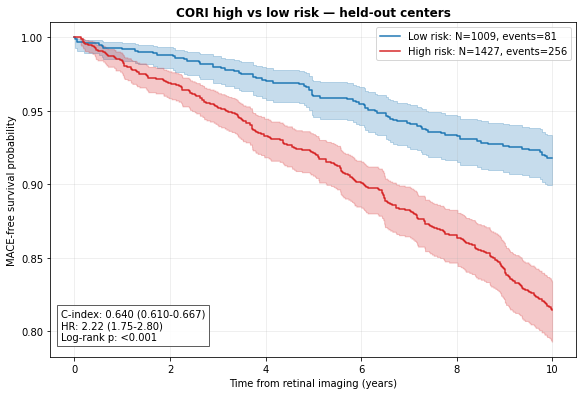

Images saved to: figures/H1_CORI_LOCKED_MODEL_v13/figures/H1_Fig02_KM_CORI_tertiles_heldout.{png,pdf,svg}


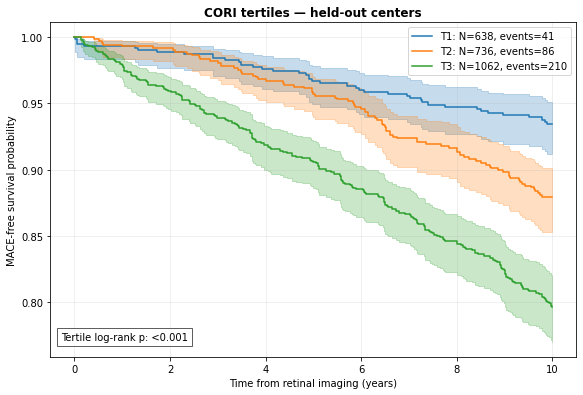


Horizon performance
          cohort  horizon_years    N  Events  C_index  C_index_low  C_index_high        C_index_95CI  HR_High_vs_Low  HR_CI_Low  HR_CI_High          HR_95CI    LogRank_p LogRank_p_fmt status
Held-out centers              3 2436      87 0.660417     0.604773      0.705432 0.660 (0.605-0.705)        1.904516   1.267906    2.860767 1.90 (1.27-2.86) 3.798537e-04        <0.001     ok
Held-out centers              5 2436     151 0.627369     0.585525      0.671685 0.627 (0.586-0.672)        1.799018   1.302711    2.484408 1.80 (1.30-2.48) 1.016104e-04        <0.001     ok
Held-out centers             10 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667)        2.215307   1.752070    2.801020 2.22 (1.75-2.80) 1.868830e-12        <0.001     ok
[shape=(3, 15)]


In [ ]:
# ============================================================
# Primary pan-cancer CORI performance
# Robust version: avoids duplicate time/event columns in horizon analyses
# ============================================================

logger.section("Primary pan-cancer CORI performance")

# ----------------------------
# 1. Primary 10-year performance using canonical time/event
# ----------------------------
perf_rows = []

for cohort_label, df_ in [
    ("Development", cancer_train),
    ("Held-out centers", cancer_test),
]:
    d = df_.copy()
    d = d.loc[:, ~d.columns.duplicated()].copy()

    perf_rows.append(
        performance_row(
            d,
            cohort_label,
            "CORI_score",
            "CORI_high_risk",
        )
    )

perf = pd.DataFrame(perf_rows)
perf.to_csv(TABLEDIR / "H1_Table_02_primary_CORI_performance_10yr.csv", index=False)
logger.df("Primary CORI performance", perf)


# ----------------------------
# 2. Held-out Kaplan-Meier plots
# ----------------------------
plot_km_high_low(
    cancer_test.loc[:, ~cancer_test.columns.duplicated()].copy(),
    "CORI_score",
    "CORI_high_risk",
    "CORI high vs low risk — held-out centers",
    FIGDIR / "H1_Fig01_KM_CORI_high_low_heldout",
)

plot_km_tertiles(
    cancer_test.loc[:, ~cancer_test.columns.duplicated()].copy(),
    "CORI_score",
    "CORI_risk_tertile",
    "CORI tertiles — held-out centers",
    FIGDIR / "H1_Fig02_KM_CORI_tertiles_heldout",
)


# ----------------------------
# 3. 3/5/10-year horizon performance
# ----------------------------
hperf = safe_horizon_performance(
    cancer_test,
    score_col="CORI_score",
    group_col="CORI_high_risk",
    horizon_cols=HORIZON_COLS,
    label="Held-out centers",
    tabledir=TABLEDIR,
    prefix="H1_Table_03_CORI",
    n_boot=300,
)

logger.df("Horizon performance", hperf)

In [ ]:
# ============================================================
# Merge final_df_HTN_DB_Status.csv into H1 train/test before clinical modeling
# ============================================================

logger.section("Merge final_df_HTN_DB_Status.csv into H1 train/test before clinical modeling")

htn_db_small = load_and_prepare_htn_db(HTN_DB_CSV)

cancer_train = merge_htn_diabetes_status(cancer_train, htn_db_small)
cancer_test = merge_htn_diabetes_status(cancer_test, htn_db_small)

print("Merged HTN/diabetes status:")
for name, df in [("cancer_train", cancer_train), ("cancer_test", cancer_test)]:
    print("\n", name, df.shape)
    for c in ["sex_clinical", "Diabetes_clinical", "HTN_clinical"]:
        if c in df.columns:
            print(c, "nonmissing=", df[c].notna().sum(), "unique=", df[c].nunique(dropna=True))


Merge final_df_HTN_DB_Status.csv into H1 train/test before clinical modeling
HTN/DB file columns:
['eid', 'Sex', 'Diabetes diagnosed by doctor', 'Age High BP diagnosed', 'Age diabetes diagnosed', 'HTN', 'Diabetes']
Merged HTN/diabetes status:

 cancer_train (2152, 1268)
sex_clinical nonmissing= 2152 unique= 2
Diabetes_clinical nonmissing= 2152 unique= 2
HTN_clinical nonmissing= 2152 unique= 2

 cancer_test (2436, 1268)
sex_clinical nonmissing= 2436 unique= 2
Diabetes_clinical nonmissing= 2436 unique= 2
HTN_clinical nonmissing= 2436 unique= 2


In [ ]:
logger.section("Clinical benchmarking: one-age clinical model, CORI-only, clinical+CORI, stacked risk model")
clinical_covars, AGE_COL = one_age_covars(cancer_train, logger=logger)
fits, clinical_comp = train_clinical_and_stacked(cancer_train, cancer_test, "CORI_score", clinical_covars, logger, TABLEDIR)
clinical_comp.to_csv(TABLEDIR / "H1_Table_04_clinical_CORI_stacked_model_comparison.csv", index=False)

coef_tables = []
for name, fit in fits.items():
    try:
        s = fit["model"].summary.reset_index().rename(columns={"covariate": "predictor", "index": "predictor"})
        s.insert(0, "model", name)
        coef_tables.append(s)
    except Exception as e:
        logger.log(f"Could not extract coefficients for {name}: {e}")
if coef_tables:
    coefs = pd.concat(coef_tables, ignore_index=True)
    coefs.to_csv(TABLEDIR / "H1_Table_05_multivariable_model_coefficients.csv", index=False)
    logger.df("Model coefficients preview", coefs.head(30))


Clinical benchmarking: one-age clinical model, CORI-only, clinical+CORI, stacked risk model
One-age clinical policy: age variable=age_at_image_visit; covariates=['age_at_image_visit', 'sex_clinical', 'Diabetes_clinical', 'HTN_clinical', 'height']

Clinical/CORI/stacked model comparison
                            model  train_N  train_events  test_N  test_events  train_C_index  test_C_index                                                                        predictors  penalizer
                         Clinical     2152           300    2436          337       0.692373      0.708638         age_at_image_visit, sex_clinical, Diabetes_clinical, HTN_clinical, height       0.05
                             CORI     2152           300    2436          337       0.639162      0.639822                                                                            CORI_z       0.01
                  Clinical + CORI     2152           300    2436          337       0.699438      0.709131 age_a


Calibration, net benefit, and predicted-risk reclassification
Images saved to: figures/H1_CORI_LOCKED_MODEL_v13/figures/H1_Fig03_reclassification_matrix_predicted_risk.{png,pdf,svg}


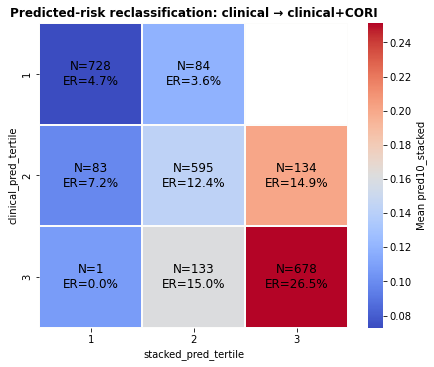

Images saved to: figures/H1_CORI_LOCKED_MODEL_v13/figures/H1_Fig04_alluvial_clinical_to_CORI.{png,pdf,svg}


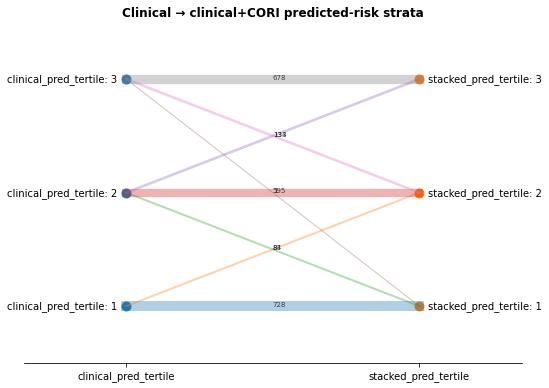


Calibration deciles
 decile   N  Events  Observed_rate  Mean_predicted_risk
      1 244       8       0.032787             0.052926
      2 244       9       0.036885             0.072683
      3 243      17       0.069959             0.091137
      4 244      17       0.069672             0.110725
      5 243      28       0.115226             0.132712
      6 244      33       0.135246             0.154045
      7 243      37       0.152263             0.176225
      8 244      37       0.151639             0.200549
      9 243      59       0.242798             0.233676
     10 244      92       0.377049             0.314122
[shape=(10, 5)]
Images saved to: figures/H1_CORI_LOCKED_MODEL_v13/figures/H1_Fig05_calibration_stacked_deciles.{png,pdf,svg}


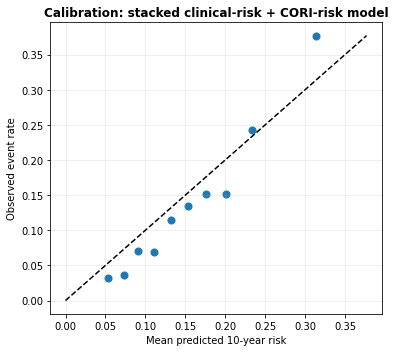

In [ ]:
logger.section("Calibration, net benefit, and predicted-risk reclassification")
# Predicted risk reclassification uses model-predicted risk, not ground-truth risk.
clin_fit = fits["Clinical"]
stack_fit = fits["Stacked clinical-risk + CORI-risk"]

clin_te = clin_fit["test_matrix"].copy()
stack_te = stack_fit["test_matrix"].copy()
clin_te["pred10_clinical"] = predict_10yr(clin_fit["model"], clin_te)
stack_te["pred10_stacked"] = predict_10yr(stack_fit["model"], stack_te)

rec = pd.DataFrame({
    "event": stack_te["event"].values,
    "pred10_stacked": stack_te["pred10_stacked"].values,
    "pred10_clinical": pd.Series(clin_te["pred10_clinical"].values, index=clin_te.index).reindex(stack_te.index).values,
}).dropna()

rec["clinical_pred_tertile"] = risk_tertiles_from_pred(rec["pred10_clinical"])
rec["stacked_pred_tertile"] = risk_tertiles_from_pred(rec["pred10_stacked"])



def transition_heatmap(df, left, right, event_col, value_col, title, save_base):
    counts, event_rates, values = transition_tables(df, left, right, event_col, value_col=value_col)

    n_rows, n_cols = values.shape
    annot = np.empty((n_rows, n_cols), dtype=object)
    for i in range(n_rows):
        for j in range(n_cols):
            n = int(counts.iloc[i, j]) if i < counts.shape[0] and j < counts.shape[1] else 0
            er = event_rates.iloc[i, j] if i < event_rates.shape[0] and j < event_rates.shape[1] else np.nan
            annot[i, j] = f"N={n}\nER={er:.1%}"

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    sns.heatmap(
        values.astype(float), annot=annot, fmt="", cmap="coolwarm", cbar=True,
        cbar_kws={"label": f"Mean {value_col}" if value_col else "Event rate"},
        linewidths=2, linecolor="#fcfcfb", annot_kws={"fontsize": 12,
                                                      "color": "black"},
        xticklabels=values.columns, yticklabels=values.index, ax=ax,
    )
    ax.set_xlabel(right); ax.set_ylabel(left); ax.set_title(title, fontweight="bold")
    fig.tight_layout()
    savefig(fig, save_base)
    plt.show()
    return counts, event_rates, values




cnt, er, mp = transition_heatmap(
    rec, "clinical_pred_tertile", "stacked_pred_tertile", "event", "pred10_stacked",
    "Predicted-risk reclassification: clinical → clinical+CORI",
    FIGDIR / "H1_Fig03_reclassification_matrix_predicted_risk"
)
cnt.to_csv(TABLEDIR / "H1_Table_06_reclassification_counts.csv")
er.to_csv(TABLEDIR / "H1_Table_07_reclassification_event_rates.csv")
mp.to_csv(TABLEDIR / "H1_Table_08_reclassification_mean_predicted_risk.csv")

alluvial_static(rec, "clinical_pred_tertile", "stacked_pred_tertile",
                "Clinical → clinical+CORI predicted-risk strata",
                FIGDIR / "H1_Fig04_alluvial_clinical_to_CORI")

# Calibration by predicted-risk decile for stacked model
rec["decile"] = pd.qcut(rec["pred10_stacked"].rank(method="first"), 10, labels=False) + 1
cal = rec.groupby("decile").agg(N=("event","size"), Events=("event","sum"), Observed_rate=("event","mean"), Mean_predicted_risk=("pred10_stacked","mean")).reset_index()
cal.to_csv(TABLEDIR / "H1_Table_09_stacked_model_calibration_deciles.csv", index=False)
logger.df("Calibration deciles", cal)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.scatter(cal["Mean_predicted_risk"], cal["Observed_rate"], s=50)
ax.plot([0, max(cal["Mean_predicted_risk"].max(), cal["Observed_rate"].max())], [0, max(cal["Mean_predicted_risk"].max(), cal["Observed_rate"].max())], linestyle="--", color="black")
ax.set_xlabel("Mean predicted 10-year risk")
ax.set_ylabel("Observed event rate")
ax.set_title("Calibration: stacked clinical-risk + CORI-risk model", fontweight="bold")
ax.grid(alpha=0.25)
fig.tight_layout()
savefig(fig, FIGDIR / "H1_Fig05_calibration_stacked_deciles")
plt.show()

## Cancer subgroup KM curves --> Not needed.

In [ ]:
# logger.section("Cancer subtype/subgroup analysis using pan-cancer CORI model only — no subgroup retraining")
# subgroup_cols = cancer_subtype_columns(cancer_test)
# logger.log(f"Detected cancer subgroup columns: {len(subgroup_cols)}")
# subgroup_perf = subgroup_analysis(
#     cancer_test, subgroup_cols, "CORI_score", "CORI_high_risk",
#     FIGDIR, TABLEDIR, min_n=50, min_events=5, prefix="H1_subgroup_pan_cancer_CORI"
# )
# logger.df("Subgroup performance", subgroup_perf)

# # Explicit interpretation reminder saved to QC
# logger.log("Subgroup analyses use the locked pan-cancer CORI model. Cases/events are MACE events within each cancer subtype; non-events are censored/event-free participants within the same subtype.")

In [ ]:
logger.section("Final H1 manifest")
manifest = {
    "notebook": "H1",
    "purpose": "Train locked pan-cancer CORI model once; downstream H2-H4 should load this model without retraining CORI.",
    "center_col": CENTER_COL,
    "train_centers_requested": TRAIN_CENTER_PATTERNS,
    "development_N": len(cancer_train),
    "development_events": int(cancer_train.event.sum()),
    "heldout_N": len(cancer_test),
    "heldout_events": int(cancer_test.event.sum()),
    "feature_selection": cori_manifest,
    "clinical_covariates": clinical_covars,
    "age_variable": AGE_COL,
    "locked_model_bundle": str(MODELDIR / "CORI_locked_model_bundle.pkl"),
}
(OUTDIR / "H1_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))


Final H1 manifest
{
  "notebook": "H1",
  "purpose": "Train locked pan-cancer CORI model once; downstream H2-H4 should load this model without retraining CORI.",
  "center_col": "UK Biobank assessment centre | Instance 0",
  "train_centers_requested": [
    "Birmingham",
    "Croydon"
  ],
  "development_N": 2152,
  "development_events": 300,
  "heldout_N": 2436,
  "heldout_events": 337,
  "feature_selection": {
    "prefix": "CORI",
    "n_initial_features": 1024,
    "n_after_variance_filter": 1024,
    "n_selected_features": 5,
    "selected_features": [
      "f260",
      "f98",
      "f989",
      "f728",
      "f319"
    ],
    "top5_features": [
      "f260",
      "f98",
      "f989",
      "f728",
      "f319"
    ],
    "top10_features": [
      "f260",
      "f98",
      "f989",
      "f728",
      "f319"
    ],
    "variance_threshold": 1e-08,
    "max_missing": 0.5,
    "cox_rank_penalizer": 0.01,
    "candidate_ks": [
      5,
      10,
      15,
      20,
      30,
   

## Subgroup analysis: Treatment

Loads locked H1 CORI and merges treatment labels.

In [ ]:
# ============================================================
# H3 setup — reuses the paths/constants declared in the shared CONFIGURATION cell above
# ============================================================
RUN_NAME = "H3_treatment_locked_CORI_v13"
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(BASE_OUTDIR / RUN_NAME)
logger = QCLogger(QCDIR / "H3_QC_log.txt")
logger.section("H3 initialized")
if not H1_CORI_BUNDLE.exists():
    raise FileNotFoundError(f"Missing H1 locked CORI bundle: {H1_CORI_BUNDLE}. Run H1 first.")

In [ ]:
logger.section("Reuse shared cancer cohort, merge treatment labels, and apply locked H1 CORI")

cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()
cohort_audit.to_csv(TABLEDIR / "H3_Table_00A_cohort_audit.csv", index=False)

cancer_train = merge_treatment_labels(cancer_train, treatment_csv=TREATMENT_CSV, chemo_csv=CHEMO_CSV, logger=logger)
cancer_test = merge_treatment_labels(cancer_test, treatment_csv=TREATMENT_CSV, chemo_csv=CHEMO_CSV, logger=logger)
treat_counts = pd.DataFrame([
    {"label": "Any systemic treatment", "N": int(cancer_train["treatment_any"].sum() + cancer_test["treatment_any"].sum())},
    {"label": "Treatment naive", "N": int(cancer_train["treatment_naive"].sum() + cancer_test["treatment_naive"].sum())},
    {"label": "Chemotherapy", "N": int(cancer_train["chemo_any"].sum() + cancer_test["chemo_any"].sum())},
    {"label": "Immunotherapy", "N": int(cancer_train["io_any"].sum() + cancer_test["io_any"].sum())},
])
treat_counts.to_csv(TABLEDIR / "H3_Table_00B_treatment_label_counts_overall.csv", index=False)
logger.df("Overall treatment counts", treat_counts)

split_table.to_csv(TABLEDIR / "H3_Table_01_center_split.csv", index=False)

# Load H1 locked CORI and apply. No CORI retraining in H3.
cori_bundle = load_model_bundle(H1_CORI_BUNDLE)
cancer_train = apply_model_bundle(cori_bundle, cancer_train, score_col="CORI_score", prefix="CORI", logger=logger)
cancer_test = apply_model_bundle(cori_bundle, cancer_test, score_col="CORI_score", prefix="CORI", logger=logger)

score_cols = [c for c in ["eid", CENTER_COL, "time", "event", "CORI_score", "CORI_high_risk", "CORI_risk_tertile", "treatment_any", "treatment_naive", "chemo_any", "io_any"] if c in cancer_test.columns]
pd.concat([
    cancer_train[score_cols].assign(split="development"),
    cancer_test[score_cols].assign(split="held_out"),
]).to_csv(TABLEDIR / "H3_Table_02_CORI_scores_with_treatment.csv", index=False)

In [ ]:
logger.section("Treatment-stratified performance and KM curves")
strata = [
    ("All held-out cancer", cancer_test),
    ("Treatment-naive", cancer_test[cancer_test["treatment_naive"].eq(1)]),
    ("Any systemic treatment", cancer_test[cancer_test["treatment_any"].eq(1)]),
    ("No chemotherapy", cancer_test[cancer_test["chemo_any"].eq(0)]),
    ("Chemotherapy", cancer_test[cancer_test["chemo_any"].eq(1)]),
    ("No immunotherapy", cancer_test[cancer_test["io_any"].eq(0)]),
    ("Immunotherapy", cancer_test[cancer_test["io_any"].eq(1)]),
]
rows = []
km_dir = FIGDIR / "H3_treatment_KM_curves"
km_dir.mkdir(parents=True, exist_ok=True)
for label, sub in strata:
    row = performance_row(sub, label, "CORI_score", "CORI_high_risk") if len(sub) else {"cohort": label, "N": 0, "Events": 0}
    row["stratum"] = label
    row["status"] = "analyzable" if row.get("N",0) >= 30 and row.get("Events",0) >= 5 else "underpowered"
    rows.append(row)
    if row["status"] == "analyzable":
        plot_km_high_low(sub, "CORI_score", "CORI_high_risk", f"H1 CORI high vs low — {label}", km_dir / f"H3_KM_{safe_name(label)}_high_low")
        if sub["CORI_risk_tertile"].nunique(dropna=True) >= 2:
            plot_km_tertiles(sub, "CORI_score", "CORI_risk_tertile", f"H1 CORI tertiles — {label}", km_dir / f"H3_KM_{safe_name(label)}_tertiles")
treat_perf = pd.DataFrame(rows)
treat_perf.to_csv(TABLEDIR / "H3_Table_03_treatment_stratified_performance.csv", index=False)
logger.df("Treatment-stratified performance", treat_perf)

fp = treat_perf.copy()
fp["label"] = fp["stratum"]
forest_plot(fp.dropna(subset=["HR_High_vs_Low"]), "label", "HR_High_vs_Low", "HR_CI_Low", "HR_CI_High", "LogRank_p", "N", "Events",
            "H1 CORI performance across treatment strata",
            FIGDIR / "H3_Fig01_treatment_forest")

In [ ]:
logger.section("3/5/10-year horizon performance in key treatment strata")

all_horizon = []

for label, sub in strata:
    hp = safe_horizon_performance(
        sub,
        score_col="CORI_score",
        group_col="CORI_high_risk",
        horizon_cols=HORIZON_COLS,
        label=label,
        tabledir=TABLEDIR,
        prefix=f"H3_{safe_name(label)}",
        n_boot=300,
    )

    if len(hp):
        all_horizon.append(hp)

if all_horizon:
    horizon_all = pd.concat(all_horizon, ignore_index=True)
    horizon_all.to_csv(
        TABLEDIR / "H3_Table_04_treatment_horizon_performance_all.csv",
        index=False,
    )
    logger.df("Treatment horizon performance", horizon_all)
else:
    horizon_all = pd.DataFrame()
    logger.log("No treatment horizon performance rows generated.")

In [ ]:
# ============================================================
# H3 — Treatment-adjusted Cox models using locked H1 CORI
# Purpose: test whether CORI is independent of systemic therapy exposure
# ============================================================

logger.section("Treatment-adjusted Cox models: locked CORI vs treatment exposure")

# ----------------------------
# 1. Z-score locked CORI using development set only
# ----------------------------
cancer_train, cancer_test, cori_z_params = zscore_from_train_apply(
    cancer_train,
    cancer_test,
    col="CORI_score",
    out_col="CORI_z",
)

pd.DataFrame([{
    "score": "CORI_score",
    "z_mean_from_development": cori_z_params["mean"],
    "z_sd_from_development": cori_z_params["sd"],
    "note": "Held-out CORI_z uses development-set mean/SD only; CORI model itself is locked.",
}]).to_csv(TABLEDIR / "H3_Table_treatment_adjustment_CORI_z_params.csv", index=False)


# ----------------------------
# 2. Treatment-adjusted models in held-out cancer cohort
# ----------------------------
treatment_covars_core = [
    "treatment_any",
    "chemo_any",
    "io_any",
]

treatment_covars_chemo_io = [
    "chemo_any",
    "io_any",
]

adjusted_tables = []

models_to_run = [
    (
        "CORI adjusted \n Any systemic",
        "CORI_z",
        ["treatment_any"],
    ),
    (
        "CORI adjusted \n Chemo & immuno",
        "CORI_z",
        treatment_covars_chemo_io,
    ),
    (
        "CORI high-risk adjusted \n Any systemic",
        "CORI_high_risk",
        ["treatment_any"],
    ),
    (
        "CORI high-risk adjusted \n Chemo & immuno",
        "CORI_high_risk",
        treatment_covars_chemo_io,
    ),
]

for label, score_col, covars in models_to_run:
    tab, model = fit_treatment_adjusted_cox(
        cancer_test,
        score_col=score_col,
        covars=covars,
        label=label,
        tabledir=TABLEDIR,
        prefix="H3",
        penalizer=0.05,
    )
    adjusted_tables.append(tab)

h3_treatment_adjusted_all = pd.concat(adjusted_tables, ignore_index=True)
h3_treatment_adjusted_all.to_csv(
    TABLEDIR / "H3_Table_treatment_adjusted_CORI_models_all.csv",
    index=False,
)

logger.df("Treatment-adjusted CORI models", h3_treatment_adjusted_all)


# ----------------------------
# 3. Forest plot for CORI terms only
# ----------------------------
cori_terms = h3_treatment_adjusted_all[
    h3_treatment_adjusted_all["variable"].isin(["CORI_z", "CORI_high_risk"])
].copy()

if len(cori_terms):
    cori_terms["label"] = cori_terms["analysis"]
    forest_plot(
        cori_terms,
        label_col="label",
        hr_col="HR",
        lo_col="HR_low",
        hi_col="HR_high",
        p_col="p",
        n_col="N",
        event_col="Events",
        title="Subgroup Analysis after treatment adjustment",
        save_base=FIGDIR / "H3_Fig_treatment_adjusted_CORI_forest",
    )
else:
    logger.log("No CORI terms available for treatment-adjusted forest plot.")

In [ ]:
logger.section("Treatment interaction likelihood-ratio tests")
clinical_covars, AGE_COL = one_age_covars(cancer_test, logger=logger)
rows = []
for flag, label in [
    ("treatment_any", "H1 CORI x any systemic treatment"),
    ("chemo_any", "H1 CORI x chemotherapy"),
    ("io_any", "H1 CORI x immunotherapy"),
]:
    if flag in cancer_test.columns:
        try:
            rows.append(lrt_interaction(cancer_test, "CORI_score", flag, covars=[], label=label + " unadjusted"))
        except Exception as e:
            rows.append({"analysis": label + " unadjusted", "status": str(e)})
        try:
            rows.append(lrt_interaction(cancer_test, "CORI_score", flag, covars=clinical_covars, label=label + " adjusted"))
        except Exception as e:
            rows.append({"analysis": label + " adjusted", "status": str(e)})
interactions = pd.DataFrame(rows)
interactions.to_csv(TABLEDIR / "H3_Table_05_treatment_interaction_LRT.csv", index=False)
logger.df("Treatment interaction LRT", interactions)

manifest = {
    "notebook": "H3",
    "purpose": "Load H1 locked CORI and evaluate treatment strata; no CORI retraining.",
    "H1_CORI_bundle": str(H1_CORI_BUNDLE),
    "treatment_files": [str(TREATMENT_CSV), str(CHEMO_CSV)],
    "clinical_covariates_for_adjusted_LRT": clinical_covars,
    "age_variable": AGE_COL,
}
(OUTDIR / "H3_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))

In [ ]:
# Handcrafted-feature comparator below reuses H1's locked HCORI bundle.
set_handcrafted_logger(logger)

# M-MACE model train

In [ ]:
# ============================================================
# H2 setup — reuses the paths/constants declared in the shared CONFIGURATION cell above
# ============================================================
RUN_NAME = "H2_MCORI_MMACE_locked_CORI_v13"
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(BASE_OUTDIR / RUN_NAME)
logger = QCLogger(QCDIR / "H2_QC_log.txt")
logger.section("H2 initialized")
if not H1_CORI_BUNDLE.exists():
    raise FileNotFoundError(f"Missing H1 locked CORI bundle: {H1_CORI_BUNDLE}. Run H1 first.")


H2 initialized


In [ ]:
logger.section("Reuse shared cancer/non-cancer cohorts and apply locked H1 CORI")

cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()
nc_train, nc_test = nc_train.copy(), nc_test.copy()

# Re-save the shared cohort audit/split tables under H2's own output folder.
cohort_audit.to_csv(TABLEDIR / "H2_Table_00A_cancer_audit.csv", index=False)
noncancer_audit.to_csv(TABLEDIR / "H2_Table_00B_noncancer_audit.csv", index=False)
split_table.to_csv(TABLEDIR / "H2_Table_01A_cancer_center_split.csv", index=False)
nc_split_table.to_csv(TABLEDIR / "H2_Table_01B_noncancer_center_split.csv", index=False)

logger.log(f"Cancer features: {len(feature_cols)}; non-cancer features available: {len(feature_cols_nc)}")

# Load H1 CORI and apply to all H2 cohorts. Do NOT retrain CORI here.
cori_bundle = load_model_bundle(H1_CORI_BUNDLE)
cancer_train = apply_model_bundle(cori_bundle, cancer_train, score_col="CORI_score", prefix="CORI", logger=logger)
cancer_test = apply_model_bundle(cori_bundle, cancer_test, score_col="CORI_score", prefix="CORI", logger=logger)
nc_train = apply_model_bundle(cori_bundle, nc_train, score_col="CORI_score", prefix="CORI", logger=logger)
nc_test = apply_model_bundle(cori_bundle, nc_test, score_col="CORI_score", prefix="CORI", logger=logger)

logger.log("Locked H1 CORI applied successfully to cancer and non-cancer cohorts.")


Reuse shared cancer/non-cancer cohorts and apply locked H1 CORI
Cancer features: 1024; non-cancer features available: 1024
{'median': 0.008059878553949969, 'tertile_1': -0.2048789296536122, 'tertile_2': 0.20255381064488825}
Applied locked CORI model to N=2152; score_col=CORI_score
{'median': 0.008059878553949969, 'tertile_1': -0.2048789296536122, 'tertile_2': 0.20255381064488825}
Applied locked CORI model to N=2436; score_col=CORI_score
{'median': 0.008059878553949969, 'tertile_1': -0.2048789296536122, 'tertile_2': 0.20255381064488825}
Applied locked CORI model to N=1408; score_col=CORI_score
{'median': 0.008059878553949969, 'tertile_1': -0.2048789296536122, 'tertile_2': 0.20255381064488825}
Applied locked CORI model to N=1933; score_col=CORI_score
Locked H1 CORI applied successfully to cancer and non-cancer cohorts.


In [ ]:
logger.section("Train non-cancer M-MACE model only")
# M-MACE is the only new retinal model trained in H2.
nc_train, nc_test, mmace_features, mmace_rank, mmace_bundle, mmace_manifest, mmace_cv = train_locked_model(
    nc_train, nc_test, feature_cols_nc, prefix="MMACE", outdir=TABLEDIR, modeldir=MODELDIR,
    logger=logger, variance_threshold=VARIANCE_THRESHOLD, max_missing=MAX_FEATURE_MISSING,
    candidate_ks=CANDIDATE_FEATURE_COUNTS, cox_rank_penalizer=UNIVARIATE_COX_PENALIZER
)
# Apply M-MACE to cancer cohorts for cross-prediction
cancer_train = apply_model_bundle(mmace_bundle, cancer_train, score_col="MMACE_score", prefix="MMACE", logger=logger)
cancer_test = apply_model_bundle(mmace_bundle, cancer_test, score_col="MMACE_score", prefix="MMACE", logger=logger)

logger.log(f"M-MACE selected features ({len(mmace_features)}): {mmace_features[:20]}")


Train non-cancer M-MACE model only

MMACE: feature selection and locked model training
MMACE: initial features=1024; retained after variance/missingness=1024
Univariate Cox ranking: 1024 usable features out of 1024

Internal development-only CV for feature count
  k  mean_c_index  sd_c_index                                               fold_c_indices                                        selection_rule
  5      0.622791    0.019103 [0.6172769378659443, 0.6484524938783613, 0.6026443828682391] smallest k within 1 SD of best CV C-index; chosen_k=5
 10      0.620519    0.019029 [0.6155291444551254, 0.6459155985969867, 0.6001134553705845] smallest k within 1 SD of best CV C-index; chosen_k=5
 15      0.623152    0.020277 [0.6206632875994057, 0.6491363526063841, 0.5996552702201471] smallest k within 1 SD of best CV C-index; chosen_k=5
 20      0.615957    0.017621 [0.6164030411605348, 0.6373122145992809, 0.5941570484148976] smallest k within 1 SD of best CV C-index; chosen_k=5
 30      0.

## CORI vs MMACE: KM curves


Cross-prediction performance, KM curves, and forest

Cross-prediction performance
                  cohort    N  Events  C_index  C_index_low  C_index_high        C_index_95CI          HR_95CI                                                   label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p                        model
    Cancer development\n 2152     300 0.639162     0.608687      0.670983 0.639 (0.609-0.671) 1.94 (1.54-2.43)        Cancer development\n | H1 CORI \n cancer-trained        1.935715   1.541476    2.430783 2.169057e-09    H1 CORI \n cancer-trained
    Cancer development\n 2152     300 0.620677     0.592312      0.648693 0.621 (0.592-0.649) 2.00 (1.58-2.53)     Cancer development\n | M-MACE \n non-cancer-trained        2.001734   1.580957    2.534503 1.225668e-09 M-MACE \n non-cancer-trained
       Cancer held-out\n 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667) 2.22 (1.75-2.80)           Cancer held-out\n | H1 CORI \n cancer-trained       

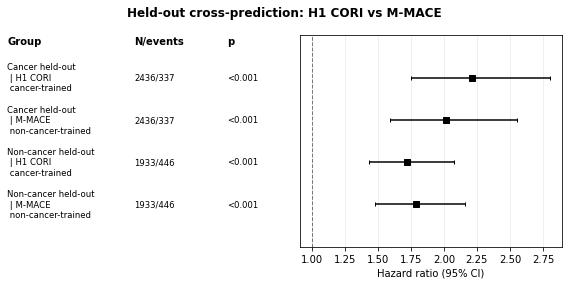

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Cancer_held_out_CORI_highlow.{png,pdf,svg}


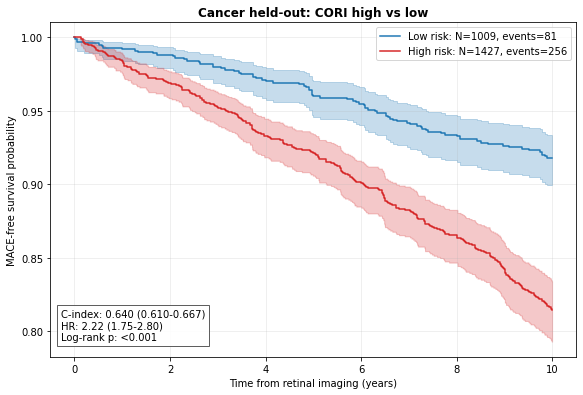

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Cancer_held_out_CORI_tertiles.{png,pdf,svg}


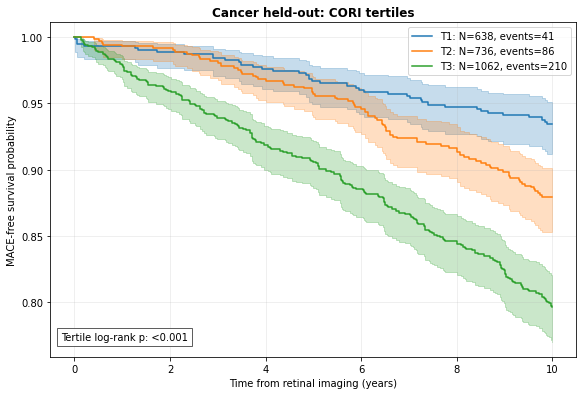

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Cancer_held_out_M-MACE_highlow.{png,pdf,svg}


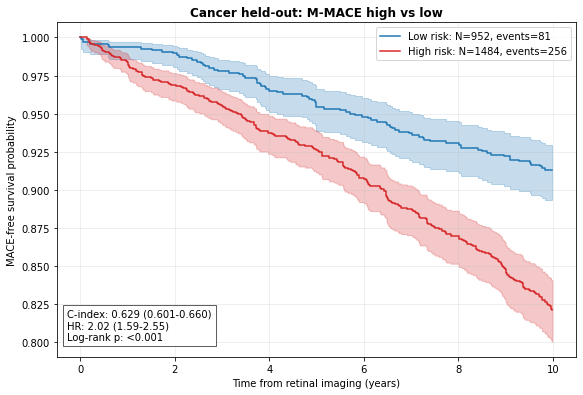

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Cancer_held_out_M-MACE_tertiles.{png,pdf,svg}


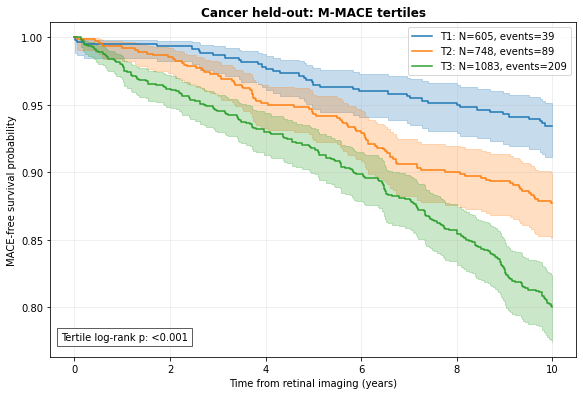

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Non_cancer_held_out_CORI_highlow.{png,pdf,svg}


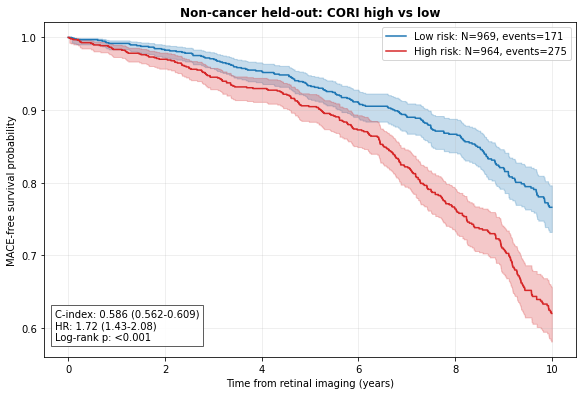

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Non_cancer_held_out_CORI_tertiles.{png,pdf,svg}


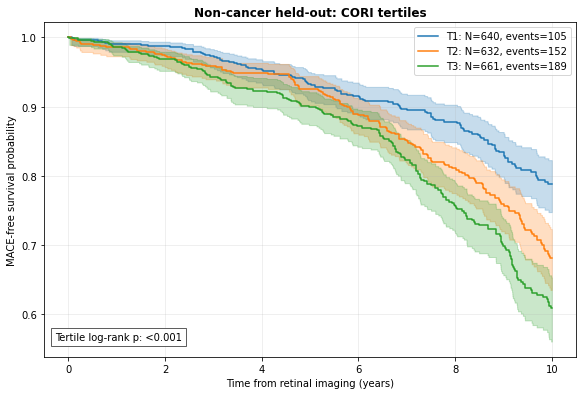

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Non_cancer_held_out_M-MACE_highlow.{png,pdf,svg}


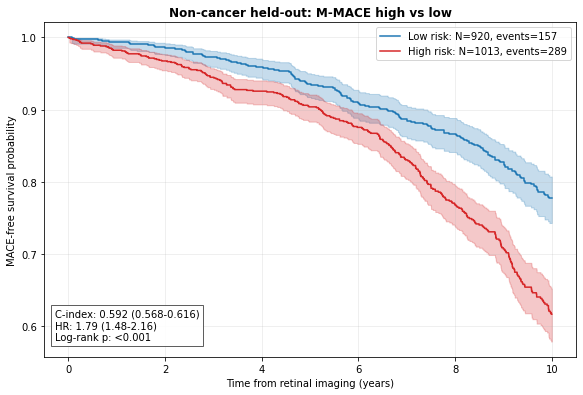

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_KM_Non_cancer_held_out_M-MACE_tertiles.{png,pdf,svg}


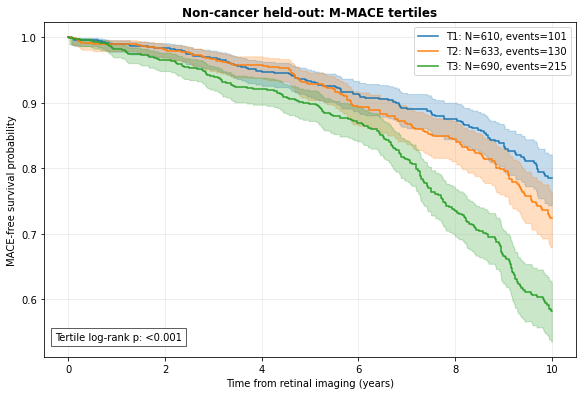

In [ ]:
logger.section("Cross-prediction performance, KM curves, and forest")
rows = []
for cohort, df in [
    ("Cancer development\n", cancer_train),
    ("Cancer held-out\n", cancer_test),
    ("Non-cancer development\n", nc_train),
    ("Non-cancer held-out\n", nc_test),
]:
    for model, score, grp in [
        ("H1 CORI \n cancer-trained", "CORI_score", "CORI_high_risk"),
        ("M-MACE \n non-cancer-trained", "MMACE_score", "MMACE_high_risk"),
    ]:
        if score in df.columns and grp in df.columns and df[score].notna().sum() > 20:
            row = performance_row(df, cohort + " | " + model, score, grp)
            row.update({"cohort": cohort, "model": model})
            rows.append(row)
perf = pd.DataFrame(rows)
perf.to_csv(TABLEDIR / "H2_Table_02_cross_prediction_performance.csv", index=False)
logger.df("Cross-prediction performance", perf)

fp = perf[perf["cohort"].str.contains("held-out", case=False, na=False)].copy()
fp["label"] = fp["cohort"] + " | " + fp["model"]
forest_plot(fp, "label", "HR_High_vs_Low", "HR_CI_Low", "HR_CI_High", "LogRank_p", "N", "Events",
            "Held-out cross-prediction: H1 CORI vs M-MACE",
            FIGDIR / "H2_Fig01_cross_prediction_forest")

for cohort, df in [("Cancer held-out", cancer_test), ("Non-cancer held-out", nc_test)]:
    for model, score, grp, ter in [
        ("CORI", "CORI_score", "CORI_high_risk", "CORI_risk_tertile"),
        ("M-MACE", "MMACE_score", "MMACE_high_risk", "MMACE_risk_tertile"),
    ]:
        plot_km_high_low(df, score, grp, f"{cohort}: {model} high vs low", FIGDIR / f"H2_KM_{safe_name(cohort)}_{model}_highlow")
        plot_km_tertiles(df, score, ter, f"{cohort}: {model} tertiles", FIGDIR / f"H2_KM_{safe_name(cohort)}_{model}_tertiles")

In [ ]:
logger.section("Cancer-status interaction likelihood-ratio tests")
pooled = pd.concat([
    cancer_test.assign(cancer_status=1, cohort="Cancer"),
    nc_test.assign(cancer_status=0, cohort="Non-cancer")
], ignore_index=True)
clinical_covars, AGE_COL = one_age_covars(pooled, logger=logger)
rows = []
for score, label in [
    ("CORI_score", "H1 CORI x cancer status"),
    ("MMACE_score", "M-MACE x cancer status"),
]:
    rows.append(lrt_interaction(pooled, score, "cancer_status", covars=[], label=label + " unadjusted"))
    rows.append(lrt_interaction(pooled, score, "cancer_status", covars=clinical_covars, label=label + " adjusted"))
interaction = pd.DataFrame(rows)
interaction.to_csv(TABLEDIR / "H2_Table_03_cancer_status_interaction_LRT.csv", index=False)
logger.df("Cancer-status interaction LRT", interaction)


Cancer-status interaction likelihood-ratio tests
One-age clinical policy: age variable=age_at_image_visit; covariates=['age_at_image_visit', 'sex_clinical', 'Diabetes_clinical', 'HTN_clinical', 'height']

Cancer-status interaction LRT
                          analysis    N  Events  LRT_chi_square  df        p  base_c_index  interaction_c_index                                                                covariates
H1 CORI x cancer status unadjusted 4369     783        9.620054   1 0.001925      0.646522             0.646241                                                                          
  H1 CORI x cancer status adjusted 4369     783        0.261185   1 0.609307      0.683693             0.683428 age_at_image_visit, sex_clinical, Diabetes_clinical, HTN_clinical, height
 M-MACE x cancer status unadjusted 4369     783        7.650620   1 0.005675      0.645282             0.645723                                                                          
   M-MACE x cancer s

## CORI - MMACE residualisation


CORI residualized against M-MACE, re-checked with KM curves
CORI ~ MMACE_score: R^2=0.6030, beta=1.2085, p=0
{'median': 0.06270312577071878, 'tertile_1': -0.3128360988128536, 'tertile_2': 0.4543366715790295}
{'median': 0.06270312577071878, 'tertile_1': -0.3128360988128536, 'tertile_2': 0.4543366715790295}

CORI residualized-against-MMACE performance
                               cohort    N  Events  C_index  C_index_low  C_index_high        C_index_95CI          HR_95CI                                 label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p
        Held-out centers | CORI (raw) 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667) 2.22 (1.75-2.80)         Held-out centers | CORI (raw)        2.215307   1.752070    2.801020 1.868830e-12
Held-out centers | CORI resid. M-MACE 2436     337 0.554522     0.525505      0.584971 0.555 (0.526-0.585) 1.28 (1.04-1.57) Held-out centers | CORI resid. M-MACE        1.277328   1.037581    1.572472 1.661191e-02
[shap

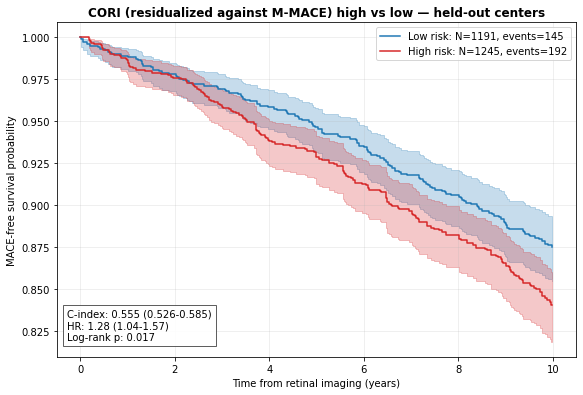

Images saved to: figures/H4_CMR_locked_CORI_v13/figures/H2_Fig03_KM_CORIresidMMACE_tertiles_heldout.{png,pdf,svg}


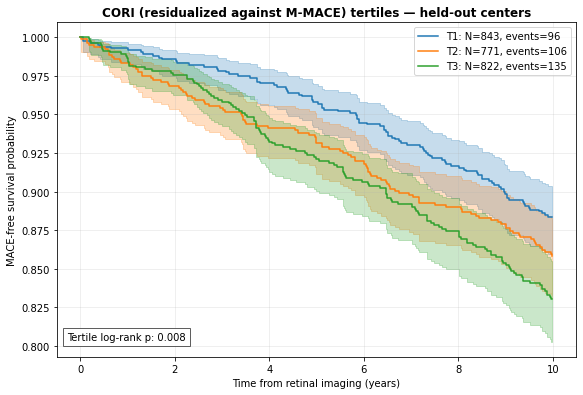

In [ ]:
# ============================================================
# CORI residualized against M-MACE — does CORI still carry
# prognostic signal once the shared retinal-MACE-risk component
# (M-MACE) is regressed out?
# ============================================================
import statsmodels.formula.api as smf

logger.section("CORI residualized against M-MACE, re-checked with KM curves")

def residualize_against_mmace(df, fit_on=None):
    """Regress CORI_score on MMACE_score, re-standardize the residual.
    Mirrors the OLS-residual-then-restandardize pattern used in
    build_adjusted_mediators (102_mediation.py)."""
    fit_df = fit_on if fit_on is not None else df
    model = smf.ols("CORI_score ~ MMACE_score", data=fit_df).fit()
    pred = model.predict(df[["MMACE_score"]])
    resid = df["CORI_score"] - pred
    resid_z = (resid - resid.mean()) / resid.std(ddof=1)
    return resid_z, model

# Fit the CORI~MMACE relationship on the training split only, apply to both splits
# (avoids leaking held-out information into the residualization, same convention
# as thresholds/model bundles elsewhere in this notebook).
_, cori_on_mmace_model = residualize_against_mmace(cancer_train)
logger.log(f"CORI ~ MMACE_score: R^2={cori_on_mmace_model.rsquared:.4f}, "
           f"beta={cori_on_mmace_model.params['MMACE_score']:.4f}, "
           f"p={cori_on_mmace_model.pvalues['MMACE_score']:.3g}")

cancer_train["CORI_resid_MMACE"], _ = residualize_against_mmace(cancer_train, fit_on=cancer_train)
cancer_test["CORI_resid_MMACE"], _ = residualize_against_mmace(cancer_test, fit_on=cancer_train)

# Derive high/low + tertile groupings from the training-split residual only,
# then apply the same cut-points to both splits (derive_thresholds /
# apply_thresholds_from_dict, as used by apply_model_bundle elsewhere in H1/H2).
resid_thresholds = derive_thresholds(cancer_train["CORI_resid_MMACE"])
cancer_train = apply_thresholds_from_dict(cancer_train, "CORI_resid_MMACE", "CORIresidMMACE", resid_thresholds)
cancer_test = apply_thresholds_from_dict(cancer_test, "CORI_resid_MMACE", "CORIresidMMACE", resid_thresholds)

# Performance table: raw CORI vs CORI-residualized-against-MMACE, held-out centers
resid_perf_rows = [
    performance_row(cancer_test, "Held-out centers | CORI (raw)", "CORI_score", "CORI_high_risk"),
    performance_row(cancer_test, "Held-out centers | CORI resid. M-MACE",
                     "CORI_resid_MMACE", "CORIresidMMACE_high_risk"),
]
resid_perf = pd.DataFrame(resid_perf_rows)
resid_perf.to_csv(TABLEDIR / "H2_Table_04_CORI_residualized_MMACE_performance.csv", index=False)
logger.df("CORI residualized-against-MMACE performance", resid_perf)

# KM curves for the residualized score, held-out centers
plot_km_high_low(
    cancer_test,
    "CORI_resid_MMACE",
    "CORIresidMMACE_high_risk",
    "CORI (residualized against M-MACE) high vs low — held-out centers",
    FIGDIR / "H2_Fig02_KM_CORIresidMMACE_high_low_heldout",
)

plot_km_tertiles(
    cancer_test,
    "CORI_resid_MMACE",
    "CORIresidMMACE_risk_tertile",
    "CORI (residualized against M-MACE) tertiles — held-out centers",
    FIGDIR / "H2_Fig03_KM_CORIresidMMACE_tertiles_heldout",
)


# new anlaysis

##  CORI vs MMACE reclassification


Predicted-risk reclassification matrices, alluvial plots, and feature-rank transition
Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_reclassification_Cancer_held_out.{png,pdf,svg}


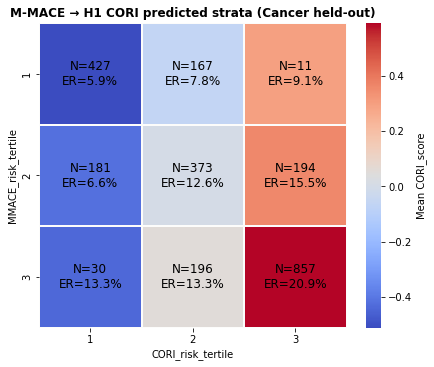

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_alluvial_Cancer_held_out.{png,pdf,svg}


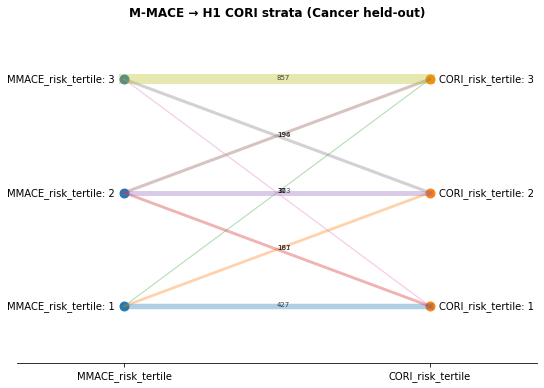

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_reclassification_Non_cancer_held_out.{png,pdf,svg}


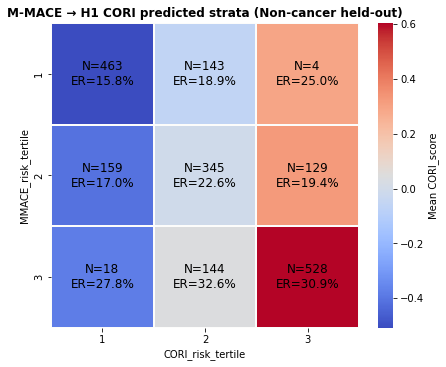

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_alluvial_Non_cancer_held_out.{png,pdf,svg}


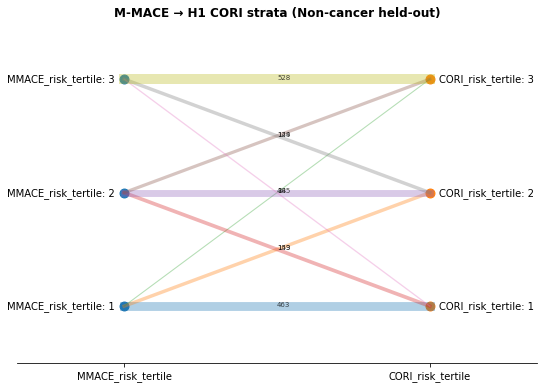

Images saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_feature_rank_transition_FIXED_COMPACT.{png,pdf,svg}


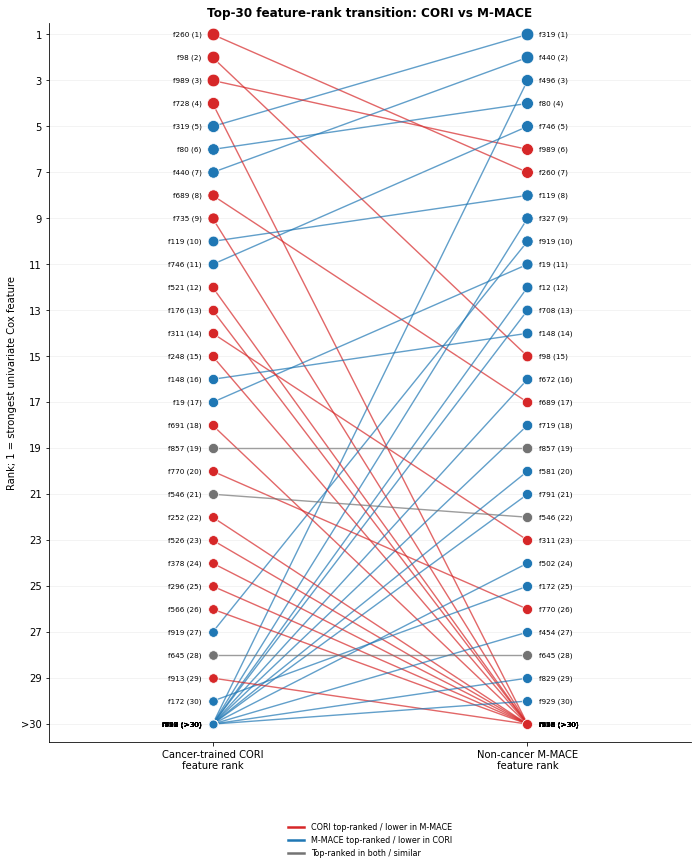

Saved fixed feature-rank plot to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_feature_rank_transition_FIXED_COMPACT.png
Y-axis capped at >30. If you still see huge whitespace, you are viewing the old file.

Feature-rank transition table
feature  CORI_rank  CORI_importance  CORI_hr  MMACE_rank  MMACE_importance  MMACE_hr  best_rank  CORI_plot_rank  MMACE_plot_rank  plot_rank_shift_MMACE_minus_CORI  full_rank_shift_MMACE_minus_CORI      membership
   f260          1         8.959088 0.715192           7          6.757544  0.777872          1               1                7                                 6                                 6     Top in both
   f319          5         7.333123 0.735978           1         10.606570  0.708452          1               5                1                                -4                                -4     Top in both
    f98          2         8.465373 1.382607          15          5.165103  1.244729          2               2       

In [ ]:
logger.section("Predicted-risk reclassification matrices, alluvial plots, and feature-rank transition")
# Reclassification compares locked CORI tertiles vs M-MACE tertiles.
for cohort, df in [("Cancer held-out", cancer_test), ("Non-cancer held-out", nc_test)]:
    rec = df[["event", "MMACE_risk_tertile", "CORI_risk_tertile", "MMACE_score", "CORI_score"]].dropna().copy()
    if len(rec) == 0:
        logger.log(f"Skipping reclassification for {cohort}: no complete rows.")
        continue
    cnt, er, mp = transition_heatmap(
        rec, "MMACE_risk_tertile", "CORI_risk_tertile", "event", "CORI_score",
        f"M-MACE → H1 CORI predicted strata ({cohort})",
        FIGDIR / f"H2_reclassification_{safe_name(cohort)}"
    )
    cnt.to_csv(TABLEDIR / f"H2_reclassification_counts_{safe_name(cohort)}.csv")
    er.to_csv(TABLEDIR / f"H2_reclassification_event_rates_{safe_name(cohort)}.csv")
    mp.to_csv(TABLEDIR / f"H2_reclassification_mean_CORI_score_{safe_name(cohort)}.csv")
    alluvial_static(rec, "MMACE_risk_tertile", "CORI_risk_tertile",
                    f"M-MACE → H1 CORI strata ({cohort})",
                    FIGDIR / f"H2_alluvial_{safe_name(cohort)}")

# Feature-rank transition: H1 CORI feature ranking vs M-MACE ranking
cori_rank = (
    cori_bundle["feature_ranking"]
    if isinstance(cori_bundle.get("feature_ranking"), pd.DataFrame)
    else pd.read_csv(H1_LOCKED_OUTDIR / "tables" / "CORI_feature_univariate_cox_ranking.csv")
)

rank_shift = feature_rank_shift_bump_FIXED(
    cori_rank,
    mmace_rank,
    FIGDIR,
    TABLEDIR,
    top_n=30,
    prefix="H2",
)

logger.df("Feature-rank transition table", rank_shift)

In [ ]:
logger.section("Final H2 manifest")
manifest = {
    "notebook": "H2",
    "purpose": "Load H1 locked CORI; train only M-MACE; compare cancer-trained vs non-cancer-trained retinal signatures.",
    "H1_CORI_bundle": str(H1_CORI_BUNDLE),
    "center_col": CENTER_COL,
    "cancer_development_N": len(cancer_train),
    "cancer_heldout_N": len(cancer_test),
    "noncancer_development_N": len(nc_train),
    "noncancer_heldout_N": len(nc_test),
    "MMACE_manifest": mmace_manifest,
    "clinical_covariates_for_LRT": clinical_covars,
    "age_variable": AGE_COL,
}
(OUTDIR / "H2_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))


Final H2 manifest
{
  "notebook": "H2",
  "purpose": "Load H1 locked CORI; train only M-MACE; compare cancer-trained vs non-cancer-trained retinal signatures.",
  "H1_CORI_bundle": "figures/H1_CORI_LOCKED_MODEL_v13/models/CORI_locked_model_bundle.pkl",
  "center_col": "UK Biobank assessment centre | Instance 0",
  "cancer_development_N": 2152,
  "cancer_heldout_N": 2436,
  "noncancer_development_N": 1408,
  "noncancer_heldout_N": 1933,
  "MMACE_manifest": {
    "prefix": "MMACE",
    "n_initial_features": 1024,
    "n_after_variance_filter": 1024,
    "n_selected_features": 5,
    "selected_features": [
      "f319",
      "f440",
      "f496",
      "f80",
      "f746"
    ],
    "top5_features": [
      "f319",
      "f440",
      "f496",
      "f80",
      "f746"
    ],
    "top10_features": [
      "f319",
      "f440",
      "f496",
      "f80",
      "f746"
    ],
    "variance_threshold": 1e-08,
    "max_missing": 0.5,
    "cox_rank_penalizer": 0.01,
    "candidate_ks": [
     

# CMR phenotyping

In [ ]:
# ============================================================
# H4 setup — reuses the paths/constants declared in the shared CONFIGURATION cell above
# ============================================================
RUN_NAME = "H4_CMR_locked_CORI_v13"
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(BASE_OUTDIR / RUN_NAME)
logger = QCLogger(QCDIR / "H4_QC_log.txt")
logger.section("H4 initialized")
if not H1_CORI_BUNDLE.exists():
    raise FileNotFoundError(f"Missing H1 locked CORI bundle: {H1_CORI_BUNDLE}. Run H1 first.")

# ============================================================
# CURATED CMR VARIABLE SPECIFICATION
# Edit this cell to control exactly which CMR phenotypes are analyzed.
# ============================================================

# 1) Optional exact CMR variable names.
# Put full cleaned CMR labels here if you want to force-include specific phenotypes.
# These names should match columns AFTER visit reshaping, i.e., without "| Instance 2/3".
# Example:
# EXACT_CMR_VARIABLES = [
#     "Left ventricular ejection fraction",
#     "Left ventricular end-diastolic volume",
#     "Descending aorta maximum area",
#     "Descending aorta distensibility",
# ]
EXACT_CMR_VARIABLES = []

# 2) Optional keywords to force-include any phenotype containing these terms.
# Keep empty unless you want a targeted analysis.
USER_CMR_KEYWORDS = []



# 4) Families to use in the primary analysis. CMR_FEATURE_FAMILIES itself (the
# family -> include/exclude regex map) is declared once in src/cmr_helper.py.
# Use "ALL_CURATED" to include every family there.
PRIMARY_CMR_FAMILIES = "ALL_CURATED"
# Or specify a focused subset, e.g.:
# PRIMARY_CMR_FAMILIES = ["LV_structure_function", "Aortic_geometry", "Aortic_stiffness_function", "Blood_pressure_PWA"]

# 5) CMR QC thresholds.
MIN_CMR_NONMISSING = 30
MIN_CMR_UNIQUE_VALUES = 5

# 6) Plot limits.
TOP_FEATURES_PER_FAMILY_FOR_TABLES = 8
TOP_FEATURES_FOR_OVERALL_PLOTS = 20


H4 initialized


In [ ]:
logger.section("Reuse shared cancer cohort and apply locked H1 CORI")

cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()
cohort_audit.to_csv(TABLEDIR / "H4_Table_00_cohort_audit.csv", index=False)
split_table.to_csv(TABLEDIR / "H4_Table_01_center_split.csv", index=False)

# Load H1 locked CORI and apply. No CORI retraining in H4.
cori_bundle = load_model_bundle(H1_CORI_BUNDLE)
cancer_train = apply_model_bundle(cori_bundle, cancer_train, score_col="CORI_score", prefix="CORI", logger=logger)
cancer_test = apply_model_bundle(cori_bundle, cancer_test, score_col="CORI_score", prefix="CORI", logger=logger)
score_df = pd.concat([cancer_train.assign(split="development"), cancer_test.assign(split="held_out")], ignore_index=True)


Reuse shared cancer cohort and apply locked H1 CORI
{'median': 0.008059878553949969, 'tertile_1': -0.2048789296536122, 'tertile_2': 0.20255381064488825}
Applied locked CORI model to N=2152; score_col=CORI_score
{'median': 0.008059878553949969, 'tertile_1': -0.2048789296536122, 'tertile_2': 0.20255381064488825}
Applied locked CORI model to N=2436; score_col=CORI_score


In [ ]:
logger.section("Load and reshape visit-aware CMR table")
if not Path(CARDIAC_MRI_CSV).exists():
    raise FileNotFoundError(f"CARDIAC_MRI_CSV not found: {CARDIAC_MRI_CSV}")
cmr = load_csv(CARDIAC_MRI_CSV, logger)
if "eid" not in cmr.columns:
    raise ValueError("CMR file must contain eid column.")
cmr["eid"] = clean_id(cmr["eid"])
cmr_long = reshape_cmr_long(cmr, instances=(2,3))
cmr_long.to_csv(TABLEDIR / "H4_Table_02_CMR_long_visit_aware.csv", index=False)
logger.log(f"CMR long shape: {cmr_long.shape}")

merge_cols = [c for c in ["eid", "time", "event", "CORI_score", "CORI_high_risk", "CORI_risk_tertile", "split"] if c in score_df.columns]
cmr_merged = cmr_long.merge(score_df[merge_cols], on="eid", how="inner")
cmr_merged.to_csv(TABLEDIR / "H4_Table_03_CORI_CMR_merged.csv", index=False)
merge_summary = cmr_merged.groupby(["split","cmr_instance"], dropna=False).agg(N=("eid","nunique"), Rows=("eid","size"), Events=("event","sum")).reset_index()
merge_summary.to_csv(TABLEDIR / "H4_Table_04_CMR_merge_summary.csv", index=False)
logger.df("CMR merge summary", merge_summary)

primary_cmr_df = cmr_merged[cmr_merged["split"].eq("held_out")].copy()
if len(primary_cmr_df) < 30:
    logger.log("Held-out CMR sample too small; using all scored CMR participants.")
    primary_cmr_df = cmr_merged.copy()
logger.log(f"Primary CMR analysis rows={len(primary_cmr_df)}, unique eids={primary_cmr_df.eid.nunique()}, events={int(primary_cmr_df.event.sum())}")


Load and reshape visit-aware CMR table
Loading CSV: data/cardiac_mri.csv
CMR long shape: (167516, 243)

CMR merge summary
      split  cmr_instance   N  Rows  Events
development             2 252   252      23
development             3 252   252      23
   held_out             2 410   410      35
   held_out             3 410   410      35
[shape=(4, 5)]
Primary CMR analysis rows=820, unique eids=410, events=70


In [ ]:
logger.section("CMR variable inventory and curated family selection")


cmr_inventory = build_cmr_variable_inventory(
    primary_cmr_df,
    CMR_FEATURE_FAMILIES,
    exact_variables=EXACT_CMR_VARIABLES,
    user_keywords=USER_CMR_KEYWORDS,
    min_nonmissing=MIN_CMR_NONMISSING,
    min_unique=MIN_CMR_UNIQUE_VALUES,
    primary_cmr_families=PRIMARY_CMR_FAMILIES,
)

cmr_inventory.to_csv(TABLEDIR / "H4_Table_05_CMR_variable_inventory_curated.csv", index=False)

selected_cmr_cols = cmr_inventory.loc[cmr_inventory["selected"], "column"].tolist()
selected_family_table = (
    cmr_inventory[cmr_inventory["selected"]]
    .groupby("family")
    .agg(
        n_features=("column", "count"),
        median_nonmissing=("nonmissing", "median"),
        min_nonmissing=("nonmissing", "min"),
        max_nonmissing=("nonmissing", "max"),
    )
    .reset_index()
    .sort_values("n_features", ascending=False)
)

selected_family_table.to_csv(TABLEDIR / "H4_Table_06_selected_CMR_feature_families.csv", index=False)

logger.df("Selected CMR feature families", selected_family_table)
logger.log(f"Selected CMR phenotypes: {len(selected_cmr_cols)}")
logger.log("Selected CMR columns:")
logger.log("\n".join(selected_cmr_cols[:100]))

if len(selected_cmr_cols) == 0:
    raise ValueError(
        "No CMR variables selected. Edit EXACT_CMR_VARIABLES, USER_CMR_KEYWORDS, "
        "CMR_FEATURE_FAMILIES, PRIMARY_CMR_FAMILIES, or lower MIN_CMR_NONMISSING."
    )


CMR variable inventory and curated family selection

Selected CMR feature families
                   family  n_features  median_nonmissing  min_nonmissing  max_nonmissing
    LV_structure_function          80              230.0             226             359
       Blood_pressure_PWA          28              368.5              33             380
          Aortic_geometry          14              184.0             164             219
         Atrial_structure           4              229.0             229             229
Aortic_stiffness_function           2              199.0             199             199
[shape=(5, 5)]
Selected CMR phenotypes: 128
Selected CMR columns:
LV ejection fraction
LV end diastolic volume
LV end systolic volume
LV stroke volume
LV end diastolic volume.1
LV end systolic volume.1
LV stroke volume.1
LV ejection fraction.1
LV cardiac output
LV myocardial mass
LV mean myocardial wall thickness AHA 1
LV mean myocardial wall thickness AHA 2
LV mean myocardial wa

In [ ]:
logger.section("Curated CMR phenotype correlations and group differences")

cmr_assoc = cmr_analysis_table(
    primary_cmr_df,
    "CORI_score",
    "CORI_high_risk",
    selected_cmr_cols,
    TABLEDIR,
    prefix="H4_curated",
)

# Add family labels to association table
if len(cmr_assoc):
    family_map_df = cmr_inventory[["column", "clean_label", "family"]].rename(columns={"column": "feature"})
    cmr_assoc = cmr_assoc.merge(family_map_df, on="feature", how="left")
    cmr_assoc = cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last")
    cmr_assoc.to_csv(TABLEDIR / "H4_Table_07_curated_CMR_associations_with_family.csv", index=False)

logger.df("Curated CMR association table", cmr_assoc.head(40) if len(cmr_assoc) else cmr_assoc)



Curated CMR phenotype correlations and group differences

Curated CMR association table
                                                    feature   N  N_low  N_high  Pearson_r    Pearson_p  Spearman_r   Spearman_p  Cohen_d_high_minus_low  Welch_p  Pearson_q  Spearman_q  Welch_q                                        clean_label                    family
                              Descending aorta minimum area 219     96     123   0.327247 7.340718e-07    0.368316 1.930249e-08                0.655861 0.000001   0.000047    0.000002 0.000191                      Descending aorta minimum area           Aortic_geometry
                            Descending aorta distensibility 199     86     113  -0.215037 2.287503e-03   -0.365212 1.133863e-07               -0.204296 0.125494   0.013943    0.000007 0.341772                    Descending aorta distensibility Aortic_stiffness_function
           Mean arterial pressure during PWA - PVR| Array 0 380    179     201   0.254556 4.931934e-0

In [ ]:

# Family-level summary: how many features in each family, and strongest feature by Spearman p
family_summary_rows = []
if len(cmr_assoc):
    for fam, g in cmr_assoc.groupby("family", dropna=False):
        g2 = g.sort_values("Spearman_p", na_position="last")
        top = g2.iloc[0]
        family_summary_rows.append({
            "family": fam,
            "n_tested": len(g),
            "top_feature": top["feature"],
            "top_feature_clean_label": top.get("clean_label", top["feature"]),
            "top_N": top["N"],
            "top_Spearman_r": top["Spearman_r"],
            "top_Spearman_p": top["Spearman_p"],
            "top_Spearman_q": top.get("Spearman_q", np.nan),
            "top_Cohen_d_high_minus_low": top.get("Cohen_d_high_minus_low", np.nan),
        })

family_summary = pd.DataFrame(family_summary_rows).sort_values("top_Spearman_p", na_position="last") if family_summary_rows else pd.DataFrame()
family_summary.to_csv(TABLEDIR / "H4_Table_08_CMR_family_summary.csv", index=False)
logger.df("CMR family summary", family_summary)


CMR family summary
                   family  n_tested                                      top_feature                 top_feature_clean_label  top_N  top_Spearman_r  top_Spearman_p  top_Spearman_q  top_Cohen_d_high_minus_low
          Aortic_geometry        14                    Descending aorta minimum area           Descending aorta minimum area    219        0.368316    1.930249e-08        0.000002                    0.655861
Aortic_stiffness_function         2                  Descending aorta distensibility         Descending aorta distensibility    199       -0.365212    1.133863e-07        0.000007                   -0.204296
       Blood_pressure_PWA        28 Mean arterial pressure during PWA - PVR| Array 0 Mean arterial pressure during PWA - PVR    380        0.257974    3.417604e-07        0.000015                    0.378749
    LV_structure_function        80         Cardiac output during PWA - PVR| Array 0         Cardiac output during PWA - PVR    359        0.181437 

Images saved to: figures/H4_CMR_locked_CORI_v13/figures/H4_Fig01_CMR_selected_family_counts.{png,pdf,svg}


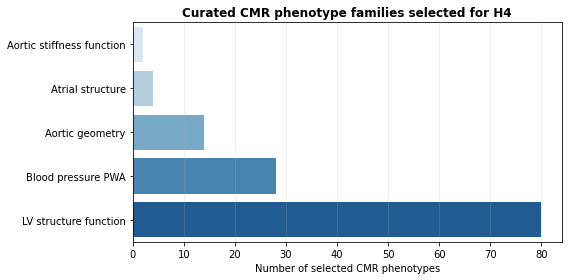

In [ ]:


# Plot family counts
if len(selected_family_table):
    fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(selected_family_table) + 1)))
    tmp = selected_family_table.sort_values("n_features", ascending=True)
    # remove "_" from family names for cleaner plotting
    tmp["family"] = tmp["family"].str.replace("_", " ")
    # seaborn barplot
    sns.barplot(
        x="n_features",
        y="family",
        data=tmp,
        ax=ax,
        palette=sns.color_palette("Blues", n_colors=len(tmp)),
    )
    ax.set_xlabel("Number of selected CMR phenotypes")
    ax.set_title("Curated CMR phenotype families selected for H4", fontweight="bold")
    ax.grid(axis="x", alpha=0.25)
    # no y label
    ax.set_ylabel("")
    fig.tight_layout()
    savefig(fig, FIGDIR / "H4_Fig01_CMR_selected_family_counts")
    plt.show()

### Violin plots : CORI high vs low MRI comparison

Images saved to: figures/H4_CMR_locked_CORI_v13/figures/H4_curated_overall_CMR_top_violin_grid.{png,pdf,svg}


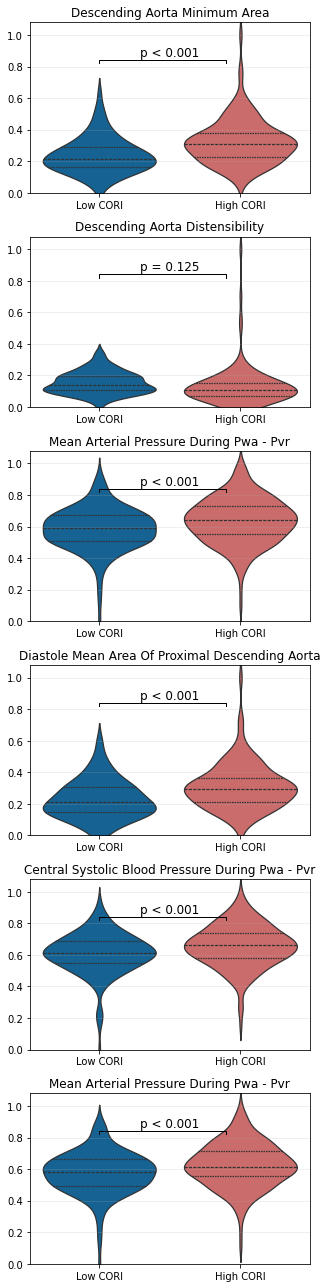

In [ ]:
# Violin plots: top features overall and by family

from scipy.stats import ttest_ind

def cmr_violin_grid(df, features, score_col, group_col, figdir, prefix="H4"):

    df = df.copy()
    feats = [f for f in features if f in df.columns][:6]

    if not feats:
        return

    n = len(feats)
    fig, axes = plt.subplots(n, 1, figsize=(4.5, 3*n), squeeze=False)

    for ax, feat in zip(axes.ravel(), feats):
        d = (
            df[[feat, group_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .copy()
        )

        # Scale to [0,1]
        d[feat] = (d[feat] - d[feat].min()) / (d[feat].max() - d[feat].min())

        g0 = pd.to_numeric(
            d.loc[d[group_col] == 0, feat], errors="coerce"
        ).dropna().values
        g1 = pd.to_numeric(
            d.loc[d[group_col] == 1, feat], errors="coerce"
        ).dropna().values

        sns.violinplot(
            data=[g0, g1],
            ax=ax,
            inner="quartile",
            palette=[color_dict["dark_blue1"], color_dict["dark_red2"]],
        )

        # Welch's t-test
        if len(g0) > 1 and len(g1) > 1:
            _, p = ttest_ind(g0, g1, equal_var=False)
            p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
            y = 0.82
            h = 0.02
            # significance bar
            ax.plot([0, 0, 0.9, 0.9], [y, y+h, y+h, y], c="black", lw=1)

            # p-value
            ax.text(0.5, y+h+0.005, p_label, ha="center", va="bottom", fontsize=12,)

        ax.set_ylim(0, 1.08)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Low CORI", "High CORI"])
        ax.set_title(feat.split("|")[0].title(), fontsize=12)
        ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    savefig(fig, Path(figdir) / f"{prefix}_CMR_top_violin_grid")
    plt.show()
    
top_overall = cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last").head(TOP_FEATURES_FOR_OVERALL_PLOTS)["feature"].tolist()
cmr_violin_grid(primary_cmr_df, top_overall, "CORI_score", "CORI_high_risk", FIGDIR, prefix="H4_curated_overall")


## Corr heatmap: MRI to MRI 

Images saved to: figures/H4_CMR_locked_CORI_v13/figures/H4_curated_family_selected_CMR_cluster_map.{png,pdf,svg}


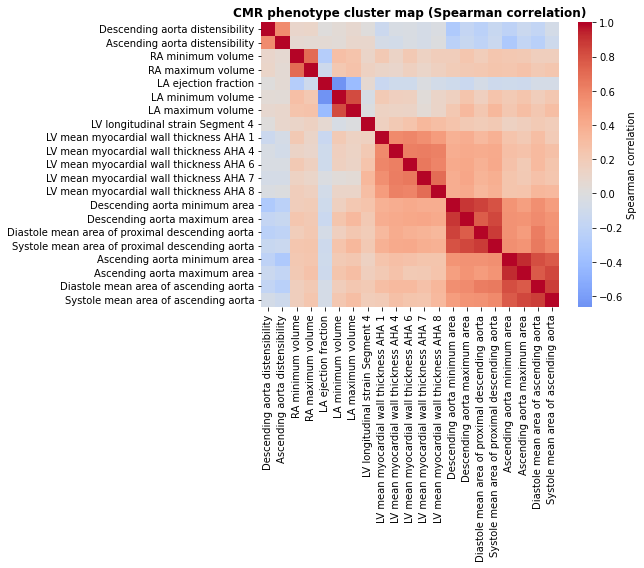

In [ ]:

def cmr_cluster_map(df, features, figdir, prefix="H4"):
    
    # df[features].info()
    # remove features with "| Array 1" or "| Array 2" in the name
    features = [f for f in features if "| Array" not in f]
    
    # split "|" from feature names for cleaner plotting
    df = df.copy()
    df.columns = [c.split("|")[0].strip() for c in df.columns]
    features = [f.split("|")[0].strip() for f in features]
    
    feats = [f for f in features if f in df.columns][:30]
    if len(feats) < 3:
        return
    X = df[feats].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median())
    corr = X.corr(method="spearman")
    try:
        dist = 1 - np.abs(corr.values)
        Z = linkage(dist[np.triu_indices_from(dist, k=1)], method="average")
        order = leaves_list(Z)
    except Exception:
        order = np.arange(len(feats))
    corr2 = corr.iloc[order, order]
    
    fig, ax = plt.subplots(figsize=(9,8))
    # use seaborn
    sns.heatmap(corr2, ax=ax, cmap="coolwarm", center=0, cbar_kws={"label": "Spearman correlation"},
                # reotate x tick labels
                xticklabels=True, yticklabels=True)

    # ax.tick_params(axis="x", labelrotation=15)

    # ax.set_xticks(range(len(corr2))); ax.set_xticklabels(corr2.columns, rotation=45, fontsize=8)
    # ax.set_yticks(range(len(corr2))); ax.set_yticklabels(corr2.index, fontsize=8)
    ax.set_title("CMR phenotype cluster map (Spearman correlation)", fontweight="bold")
    fig.tight_layout()
    savefig(fig, Path(figdir)/f"{prefix}_CMR_cluster_map")
    plt.show()
    

# Top features per family for supplemental inspection
top_by_family = []
for fam, g in cmr_assoc.groupby("family", dropna=False):
    top_by_family.extend(g.sort_values("Spearman_p", na_position="last").head(TOP_FEATURES_PER_FAMILY_FOR_TABLES)["feature"].tolist())
top_by_family = list(dict.fromkeys(top_by_family))
pd.DataFrame({"feature": top_by_family}).to_csv(TABLEDIR / "H4_Table_09_top_CMR_features_by_family_for_plots.csv", index=False)

# Cluster map on top curated features only
cmr_cluster_map(primary_cmr_df, top_by_family[:30], FIGDIR, prefix="H4_curated_family_selected")


## Volcano-style plot with family coloring

In [ ]:
 
# plot_df = cmr_assoc.copy()
# plot_df["minus_log10_p"] = -np.log10(plot_df["Spearman_p"].replace(0, np.nan))

# families = sorted(plot_df["family"].fillna("Unclassified").unique())
# fam_to_num = {f: i for i, f in enumerate(families)}
# plot_df["_fam_num"] = plot_df["family"].fillna("Unclassified").map(fam_to_num)

# fig, ax = plt.subplots(figsize=(8.2, 5.6))
# sc = ax.scatter(
#     plot_df["Spearman_r"],
#     plot_df["minus_log10_p"],
#     c=plot_df["_fam_num"],
#     alpha=0.78,
#     s=42,
# )

# for _, r in plot_df.sort_values("Spearman_p").head(10).iterrows():
#     label = str(r.get("clean_label", r["feature"]))[:38]
#     ax.text(r["Spearman_r"], r["minus_log10_p"], label, fontsize=7)

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with CORI")
# ax.set_ylabel("-log10(p)")
# ax.set_title("Curated CMR phenotypes associated with locked H1 CORI", fontweight="bold")
# ax.grid(alpha=0.25)

# # Compact legend by family
# handles = []
# for fam, num in fam_to_num.items():
#     handles.append(plt.Line2D([0], [0], marker='o', linestyle='', label=fam, markersize=6))
# ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)

# fig.tight_layout()
# savefig(fig, FIGDIR / "H4_Fig02_CMR_volcano_curated_by_family")
# plt.show()


Adjusted CMR regressions on curated feature set
One-age clinical policy: age variable=None; covariates=[]

Adjusted CMR regressions on curated features
                                                    feature   N  beta_per_1SD_CORI       se    ci_low   ci_high            p        q                                        clean_label                    family
           Mean arterial pressure during PWA - PVR| Array 0 380           0.254556 0.049740  0.157065  0.352047 3.092499e-07 0.000003            Mean arterial pressure during PWA - PVR        Blood_pressure_PWA
                              Descending aorta minimum area 219           0.327247 0.064147  0.201519  0.452974 3.368973e-07 0.000003                      Descending aorta minimum area           Aortic_geometry
  Central systolic blood pressure during PWA - PVR| Array 0 380           0.244068 0.049879  0.146305  0.341831 9.920452e-07 0.000007   Central systolic blood pressure during PWA - PVR        Blood_pressure_PWA
   

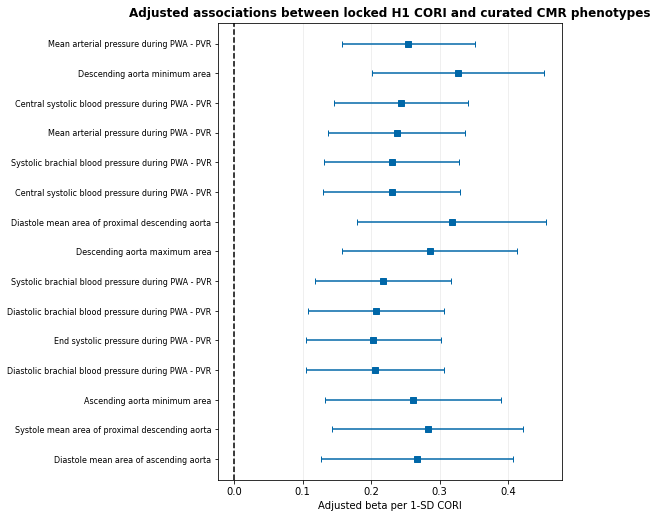

{
  "notebook": "H4",
  "purpose": "Load H1 locked CORI and evaluate explicitly curated visit-aware CMR phenotype families; no CORI retraining.",
  "H1_CORI_bundle": "figures/H1_CORI_LOCKED_MODEL_v13/models/CORI_locked_model_bundle.pkl",
  "CARDIAC_MRI_CSV": "data/cardiac_mri.csv",
  "primary_CMR_rows": 820,
  "primary_CMR_unique_eids": 410,
  "CMR_feature_families": {
    "LV_structure_function": {
      "include": [
        "\\bleft ventricular\\b",
        "\\bLV\\b",
        "end[- ]diastolic volume",
        "end[- ]systolic volume",
        "stroke volume",
        "ejection fraction",
        "cardiac output",
        "myocardial mass",
        "left ventricle"
      ],
      "exclude": [
        "image",
        "date",
        "quality",
        "path"
      ]
    },
    "RV_structure_function": {
      "include": [
        "\\bright ventricular\\b",
        "\\bRV\\b",
        "right ventricle",
        "end[- ]diastolic volume",
        "end[- ]systolic volume",
        "str

In [ ]:
logger.section("Adjusted CMR regressions on curated feature set")

clinical_covars, AGE_COL = one_age_covars(primary_cmr_df, logger=logger)

# Do adjusted regressions on top curated features, not random numeric columns.
if len(cmr_assoc):
    features_for_reg = (
        cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last")
        .head(TOP_FEATURES_FOR_OVERALL_PLOTS)["feature"]
        .tolist()
    )
else:
    features_for_reg = []

pd.DataFrame({"feature_for_adjusted_regression": features_for_reg}).to_csv(
    TABLEDIR / "H4_Table_10_features_entering_adjusted_CMR_regressions.csv",
    index=False,
)

reg_table = adjusted_linear_regressions(
    primary_cmr_df,
    "CORI_score",
    features_for_reg,
    clinical_covars,
    TABLEDIR,
    prefix="H4_curated",
)

if len(reg_table):
    reg_table = reg_table.merge(
        cmr_inventory[["column", "clean_label", "family"]].rename(columns={"column": "feature"}),
        on="feature",
        how="left",
    )
    reg_table = reg_table.sort_values("p", na_position="last")
    reg_table.to_csv(TABLEDIR / "H4_Table_11_adjusted_CMR_regressions_curated_with_family.csv", index=False)

logger.df("Adjusted CMR regressions on curated features", reg_table.head(30) if len(reg_table) else reg_table)

# Forest-style adjusted beta plot
if len(reg_table):
    fp = (
        reg_table.dropna(subset=["beta_per_1SD_CORI", "ci_low", "ci_high"])
        .sort_values("p")
        .head(15)
        .iloc[::-1]
        .copy()
    )
    if len(fp):
        labels = fp["clean_label"].fillna(fp["feature"]).astype(str).str.slice(0, 55)
        fig, ax = plt.subplots(figsize=(8.0, max(4, 0.42 * len(fp) + 1)))
        y = np.arange(len(fp))
        ax.errorbar(
            fp["beta_per_1SD_CORI"],
            y,
            xerr=[
                fp["beta_per_1SD_CORI"] - fp["ci_low"],
                fp["ci_high"] - fp["beta_per_1SD_CORI"],
            ],
            fmt="s",
            capsize=3,
            color=color_dict["dark_blue1"]
        )
        ax.axvline(0, color="black", linestyle="--")
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Adjusted beta per 1-SD CORI")
        ax.set_title("Adjusted associations between locked H1 CORI and curated CMR phenotypes", fontweight="bold")
        ax.grid(axis="x", alpha=0.25)
        fig.tight_layout()
        savefig(fig, FIGDIR / "H4_Fig03_adjusted_CMR_beta_forest_curated")
        plt.show()

manifest = {
    "notebook": "H4",
    "purpose": "Load H1 locked CORI and evaluate explicitly curated visit-aware CMR phenotype families; no CORI retraining.",
    "H1_CORI_bundle": str(H1_CORI_BUNDLE),
    "CARDIAC_MRI_CSV": str(CARDIAC_MRI_CSV),
    "primary_CMR_rows": len(primary_cmr_df),
    "primary_CMR_unique_eids": int(primary_cmr_df.eid.nunique()) if "eid" in primary_cmr_df.columns else None,
    "CMR_feature_families": CMR_FEATURE_FAMILIES,
    "PRIMARY_CMR_FAMILIES": PRIMARY_CMR_FAMILIES,
    "EXACT_CMR_VARIABLES": EXACT_CMR_VARIABLES,
    "USER_CMR_KEYWORDS": USER_CMR_KEYWORDS,
    "MIN_CMR_NONMISSING": MIN_CMR_NONMISSING,
    "MIN_CMR_UNIQUE_VALUES": MIN_CMR_UNIQUE_VALUES,
    "n_selected_CMR_features": len(selected_cmr_cols),
    "selected_CMR_features": selected_cmr_cols,
    "clinical_covariates_for_adjusted_regression": clinical_covars,
    "age_variable": AGE_COL,
}

(OUTDIR / "H4_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))

# H-CORI Handcrafted

In [ ]:
# AUTO-HANDCRAFTED-FINAL-v3 — common handcrafted feature utilities
# This cell is self-contained and does not modify the RetFound CORI model.

set_handcrafted_logger(logger)

HANDCRAFTED_H1_OUTDIR = H1_HCORI_OUTDIR
HANDCRAFTED_H1_MODELDIR = HANDCRAFTED_H1_OUTDIR / "models"
HANDCRAFTED_H1_TABLEDIR = HANDCRAFTED_H1_OUTDIR / "tables"
HANDCRAFTED_H1_FIGDIR = HANDCRAFTED_H1_OUTDIR / "figures"
for _p in [HANDCRAFTED_H1_OUTDIR, HANDCRAFTED_H1_MODELDIR, HANDCRAFTED_H1_TABLEDIR, HANDCRAFTED_H1_FIGDIR]:
    _p.mkdir(parents=True, exist_ok=True)


H1 handcrafted retinal comparator: train cancer-trained HCORI
Loading cached handcrafted features from CSV: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv
Handcrafted feature table shape: (54060, 456)
Elapsed after feature loading: 0.09 min


,set,N,with_any_HC,n_HC_columns,id_col
0,development,2152,2003,453,eid
1,held_out,2436,2250,453,eid


Merge complete in 0.01 min

Fast handcrafted feature prefilter before Cox ranking
HC columns before prefilter: 453
HC columns after prefilter: 453
Using top 75 handcrafted features for Cox ranking/modeling out of 453 prefiltered features.
Fast HC train shape: (2152, 1351)
Fast HC test shape : (2436, 1351)
HCORI: candidate handcrafted columns after filters: 75
HCORI model training complete in 0.09 min


,cohort,model,N,Events,C_index,HR_high_vs_low,HR_low,HR_high,HR_95CI,p,p_fmt
0,Development,HCORI,2152,300,0.585703,1.384685,1.107664,1.730988,1.38 (1.11-1.73),4.265961e-03,0.004
1,Held-out centers,HCORI,2436,337,0.558060,1.217720,0.988597,1.499945,1.22 (0.99-1.50),6.400667e-02,0.064
2,Held-out centers,CORI,2436,337,0.639822,2.215307,1.752070,2.801020,2.22 (1.75-2.80),3.026253e-11,<0.001


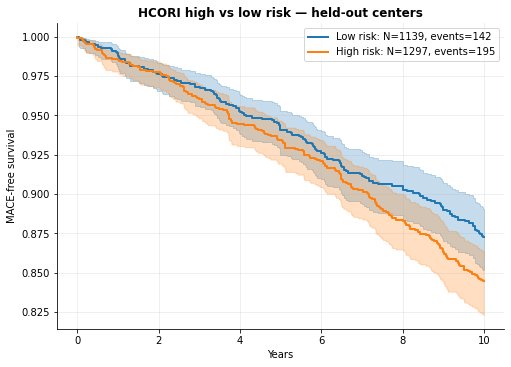

Saved locked HCORI bundle to: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/models/HCORI_locked_handcrafted_model_bundle.pkl
Total H1 handcrafted cell runtime: 0.20 min


In [ ]:
# ============================================================
# AUTO-HANDCRAFTED-FINAL-v3 — H1 handcrafted HCORI comparator
# FAST / CACHE-SAFE VERSION
# ============================================================

import time

_hc_section("H1 handcrafted retinal comparator: train cancer-trained HCORI")

# ----------------------------
# Speed controls
# ----------------------------
REBUILD_HANDCRAFTED_CACHE = False

# Set this to a reasonable number first.
# You can increase to 100/200 later if the first run works.
MAX_HANDCRAFTED_FEATURES_FOR_RANKING = 75

# Basic filters before Cox ranking
HC_MAX_MISSING = 0.50
HC_MIN_VARIANCE = 1e-8
HC_MIN_NONMISSING_TRAIN = 50

cache_parquet = HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_subject_level_features_cached.parquet"
cache_csv = HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_subject_level_features_cached.csv"

t0 = time.time()

# ----------------------------
# 1. Load handcrafted features once, then cache
# ----------------------------
if (not REBUILD_HANDCRAFTED_CACHE) and cache_parquet.exists():
    _hc_log(f"Loading cached handcrafted features from parquet: {cache_parquet}")
    hc_features = pd.read_parquet(cache_parquet)
    hc_errors = pd.DataFrame()

elif (not REBUILD_HANDCRAFTED_CACHE) and cache_csv.exists():
    _hc_log(f"Loading cached handcrafted features from CSV: {cache_csv}")
    hc_features = pd.read_csv(cache_csv, low_memory=False)
    hc_errors = pd.DataFrame()

else:
    _hc_log(f"Reading raw handcrafted CSV files from: {HANDCRAFTED_FEATURE_DIR}")
    _hc_log("This can be slow the first time. The result will be cached.")

    t_load = time.time()
    hc_features, hc_errors = load_handcrafted_features(
        HANDCRAFTED_FEATURE_DIR,
        id_col_name="eid",
    )
    _hc_log(f"Raw handcrafted load complete in {(time.time() - t_load)/60:.2f} min")

    # Save cache
    try:
        hc_features.to_parquet(cache_parquet, index=False)
        _hc_log(f"Saved parquet cache: {cache_parquet}")
    except Exception as e:
        _hc_log(f"Could not save parquet cache: {e}")

    hc_features.to_csv(cache_csv, index=False)
    _hc_log(f"Saved CSV cache: {cache_csv}")

    if len(hc_errors):
        hc_errors.to_csv(
            HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_feature_read_errors.csv",
            index=False,
        )

_hc_log(f"Handcrafted feature table shape: {hc_features.shape}")
_hc_log(f"Elapsed after feature loading: {(time.time() - t0)/60:.2f} min")


# ----------------------------
# 2. Merge with H1 train/test
# ----------------------------
t_merge = time.time()

cancer_train_hc, hc_id_train = merge_handcrafted(cancer_train, hc_features)
cancer_test_hc, hc_id_test = merge_handcrafted(cancer_test, hc_features)

hc_cols_all = [c for c in cancer_train_hc.columns if str(c).startswith("HC_")]

merge_qc = pd.DataFrame([
    {
        "set": "development",
        "N": len(cancer_train_hc),
        "with_any_HC": int(cancer_train_hc[hc_cols_all].notna().any(axis=1).sum()) if hc_cols_all else 0,
        "n_HC_columns": len(hc_cols_all),
        "id_col": hc_id_train,
    },
    {
        "set": "held_out",
        "N": len(cancer_test_hc),
        "with_any_HC": int(cancer_test_hc[hc_cols_all].notna().any(axis=1).sum()) if hc_cols_all else 0,
        "n_HC_columns": len(hc_cols_all),
        "id_col": hc_id_test,
    },
])

merge_qc.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_merge_QC.csv",
    index=False,
)
display(merge_qc)

_hc_log(f"Merge complete in {(time.time() - t_merge)/60:.2f} min")


# ----------------------------
# 3. Fast prefilter handcrafted columns before Cox ranking
# ----------------------------
_hc_section("Fast handcrafted feature prefilter before Cox ranking")

prefilter_rows = []
candidate_hc_cols = []

for c in hc_cols_all:
    x = pd.to_numeric(cancer_train_hc[c], errors="coerce")
    n_nonmiss = int(x.notna().sum())
    miss = float(x.isna().mean())
    var = float(x.var(skipna=True)) if n_nonmiss > 1 else np.nan

    keep = (
        n_nonmiss >= HC_MIN_NONMISSING_TRAIN
        and miss <= HC_MAX_MISSING
        and np.isfinite(var)
        and var > HC_MIN_VARIANCE
    )

    prefilter_rows.append({
        "feature": c,
        "n_nonmissing_train": n_nonmiss,
        "missing_fraction_train": miss,
        "variance_train": var,
        "status": "keep" if keep else "drop",
    })

    if keep:
        candidate_hc_cols.append(c)

prefilter_df = pd.DataFrame(prefilter_rows)
prefilter_df.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_prefilter_QC.csv",
    index=False,
)

_hc_log(f"HC columns before prefilter: {len(hc_cols_all)}")
_hc_log(f"HC columns after prefilter: {len(candidate_hc_cols)}")

# Optional fast ranking by simple univariate event/non-event mean difference
# to avoid Cox-fitting thousands of variables.
rank_rows = []
for c in candidate_hc_cols:
    x = pd.to_numeric(cancer_train_hc[c], errors="coerce")
    e = pd.to_numeric(cancer_train_hc["event"], errors="coerce").fillna(0).astype(int)

    x0 = x[e.eq(0)].dropna()
    x1 = x[e.eq(1)].dropna()

    if len(x0) < 20 or len(x1) < 5:
        score = np.nan
    else:
        pooled = np.sqrt((x0.var(ddof=1) + x1.var(ddof=1)) / 2)
        score = abs((x1.mean() - x0.mean()) / pooled) if pooled and np.isfinite(pooled) else np.nan

    rank_rows.append({"feature": c, "fast_abs_standardized_difference": score})

fast_rank = (
    pd.DataFrame(rank_rows)
    .sort_values("fast_abs_standardized_difference", ascending=False, na_position="last")
)

fast_rank.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_fast_univariate_prefilter_rank.csv",
    index=False,
)

selected_for_modeling = (
    fast_rank["feature"]
    .dropna()
    .head(MAX_HANDCRAFTED_FEATURES_FOR_RANKING)
    .tolist()
)

_hc_log(
    f"Using top {len(selected_for_modeling)} handcrafted features for Cox ranking/modeling "
    f"out of {len(candidate_hc_cols)} prefiltered features."
)

pd.DataFrame({"HC_feature_used_for_modeling": selected_for_modeling}).to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_features_passed_to_survival_model.csv",
    index=False,
)


# ----------------------------
# 4. Train HCORI on the reduced handcrafted feature set
# ----------------------------
# Temporarily restrict train/test to the selected handcrafted columns + required survival columns.
required_cols = ["eid", "time", "event"]
optional_cols = [
    c for c in cancer_train_hc.columns
    if c not in selected_for_modeling and not str(c).startswith("HC_")
]

# Keep original metadata plus selected HC columns.
cancer_train_hc_fast = cancer_train_hc[
    [c for c in cancer_train_hc.columns if not str(c).startswith("HC_")] + selected_for_modeling
].copy()

cancer_test_hc_fast = cancer_test_hc[
    [c for c in cancer_test_hc.columns if not str(c).startswith("HC_")] + selected_for_modeling
].copy()

_hc_log(f"Fast HC train shape: {cancer_train_hc_fast.shape}")
_hc_log(f"Fast HC test shape : {cancer_test_hc_fast.shape}")

t_train = time.time()

cancer_train_hc_fast, cancer_test_hc_fast, hcori_features, hcori_rank, hcori_bundle, hcori_cv = train_handcrafted_survival_model(
    cancer_train_hc_fast,
    cancer_test_hc_fast,
    prefix="HCORI",
    outdir=HANDCRAFTED_H1_OUTDIR,
)

_hc_log(f"HCORI model training complete in {(time.time() - t_train)/60:.2f} min")


# ----------------------------
# 5. Copy HCORI outputs back to main H1 train/test
# ----------------------------
for col in ["HCORI_score", "HCORI_high_risk", "HCORI_risk_tertile"]:
    cancer_train[col] = cancer_train_hc_fast[col].values
    cancer_test[col] = cancer_test_hc_fast[col].values


# ----------------------------
# 6. Performance table and KM
# ----------------------------
perf_rows = [
    hc_performance_row(cancer_train, "Development", "HCORI_score", "HCORI_high_risk"),
    hc_performance_row(cancer_test, "Held-out centers", "HCORI_score", "HCORI_high_risk"),
]

if "CORI_score" in cancer_test.columns:
    perf_rows.append(
        hc_performance_row(
            cancer_test,
            "Held-out centers",
            "CORI_score",
            "CORI_high_risk" if "CORI_high_risk" in cancer_test.columns else None,
        )
    )

hc_perf = pd.DataFrame(perf_rows)
hc_perf.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_vs_retfound_performance.csv",
    index=False,
)
display(hc_perf)

plot_hc_km(
    cancer_test,
    "HCORI_high_risk",
    "HCORI high vs low risk — held-out centers",
    HANDCRAFTED_H1_FIGDIR / "H1_HCORI_KM_high_low_heldout",
)

_hc_log(f"Saved locked HCORI bundle to: {HANDCRAFTED_H1_MODELDIR / 'HCORI_locked_handcrafted_model_bundle.pkl'}")
_hc_log(f"Total H1 handcrafted cell runtime: {(time.time() - t0)/60:.2f} min")


H2 handcrafted comparison: locked HCORI vs non-cancer H-M-MACE using cached features
Loading cached handcrafted features from: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv
Cached handcrafted rows before duplicate removal: 54060
Cached handcrafted unique subjects: 54060
Usable numeric handcrafted feature columns: 454


,cache_path,n_rows_raw,n_unique_subjects,n_numeric_features,numeric_feature_examples
0,figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_H...,54060,54060,454,"[HC_vessel_All_pixel_degree_1, HC_vessel_All_p..."


,cohort,cohort_rows_raw,cohort_unique_eids,handcrafted_rows_raw,handcrafted_unique_eids,merged_rows,matched_rows_any_handcrafted_feature,unmatched_rows,match_rate,n_numeric_handcrafted_features_available,n_handcrafted_features_added,feature_examples,status
0,cancer_train,2152,2152,54060,54060,2152,2003,149,0.930762,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok
1,cancer_test,2436,2436,54060,54060,2436,2250,186,0.923645,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok
2,noncancer_train,1408,1408,54060,54060,1408,1408,0,1.000000,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok
3,noncancer_test,1933,1933,54060,54060,1933,1933,0,1.000000,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok


Merged handcrafted cohort shapes:
  cancer_train_hc: (2152, 1728)
  cancer_test_hc : (2436, 1728)
  nc_train_hc    : (1408, 2083)
  nc_test_hc     : (1933, 2083)

Handcrafted merge QC:
         cohort  cohort_rows_raw  cohort_unique_eids  handcrafted_rows_raw  handcrafted_unique_eids  merged_rows  matched_rows_any_handcrafted_feature  unmatched_rows  match_rate  n_numeric_handcrafted_features_available  n_handcrafted_features_added                                                                                                                                                                                                                                                                                                                                                           feature_examples status
   cancer_train             2152                2152                 54060                    54060         2152                                  2003             149    0.930762                

,cohort,model,N,Events,C_index,HR_high_vs_low,HR_low,HR_high,HR_95CI,p,p_fmt,score_col,group_col
0,Cancer held-out,HCORI cancer-trained handcrafted,2436,337,0.558060,1.217720,0.988597,1.499945,1.22 (0.99-1.50),0.064007,0.064,HCORI_score,HCORI_high_risk
1,Cancer held-out,H-M-MACE non-cancer-trained handcrafted,2436,337,0.572849,1.462990,1.178427,1.816268,1.46 (1.18-1.82),0.000565,<0.001,HMMACE_score,HMMACE_high_risk
2,Non-cancer held-out,HCORI cancer-trained handcrafted,1933,446,0.555202,1.333805,1.112068,1.599755,1.33 (1.11-1.60),0.001903,0.002,HCORI_score,HCORI_high_risk
3,Non-cancer held-out,H-M-MACE non-cancer-trained handcrafted,1933,446,0.563429,1.464720,1.220357,1.758014,1.46 (1.22-1.76),0.000042,<0.001,HMMACE_score,HMMACE_high_risk


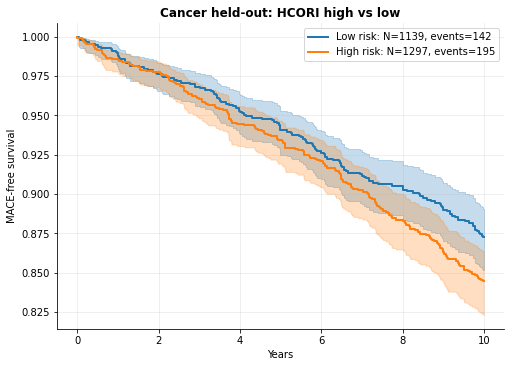

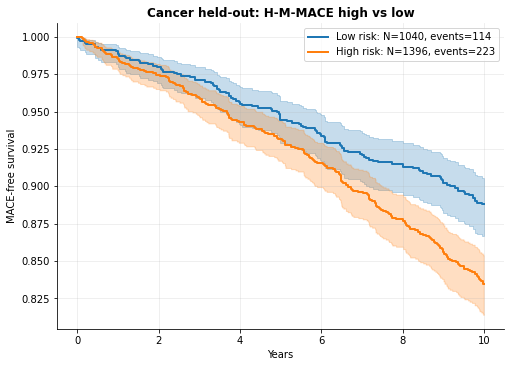

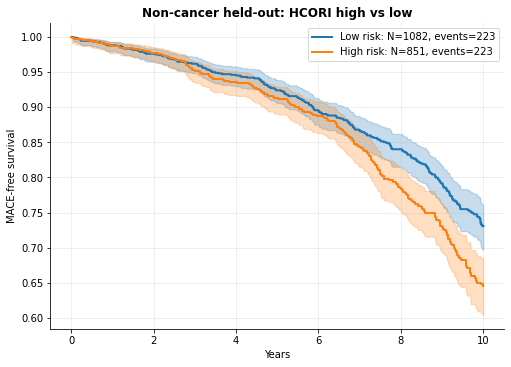

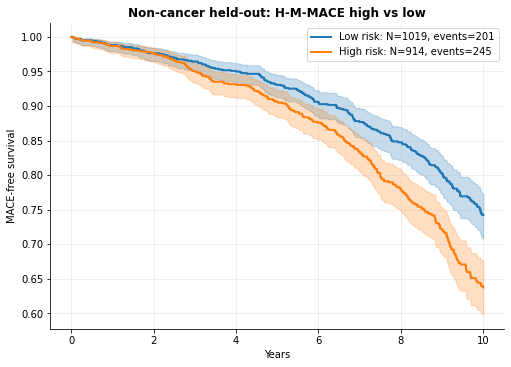

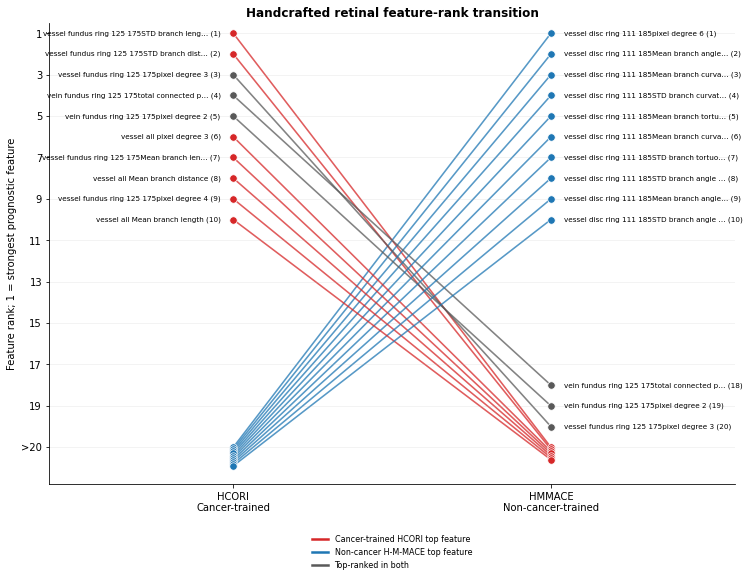

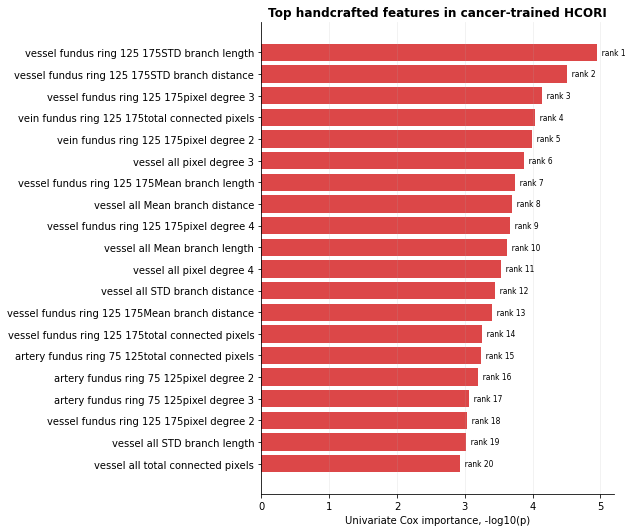

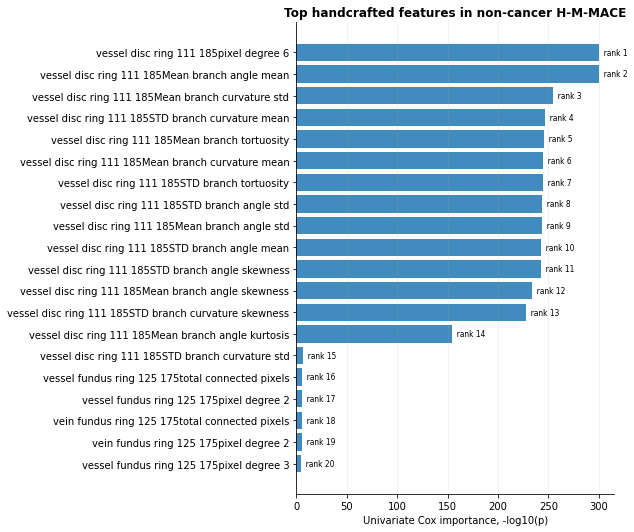

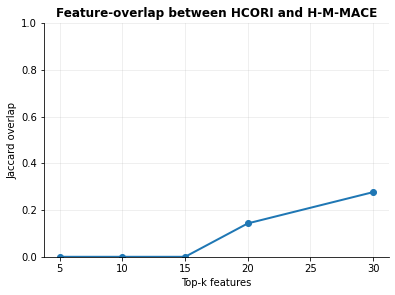

H2 cached handcrafted analysis complete.
Outputs saved to: figures/H4_CMR_locked_CORI_v13/handcrafted_HMMACE


In [ ]:
# ============================================================
# AUTO-HANDCRAFTED-FINAL-v3 — H2 handcrafted HCORI vs H-M-MACE comparison
# CACHE-BASED VERSION: does NOT read one-CSV-per-subject from OneDrive
# ============================================================

_hc_section("H2 handcrafted comparison: locked HCORI vs non-cancer H-M-MACE using cached features")

# ------------------------------------------------------------
# 0. Locate cached handcrafted feature matrix
# ------------------------------------------------------------
# Preferred: H1 should have already created one of these cache files.
# Edit this list if your H1 cache has a different filename.

HANDCRAFTED_CACHE_CANDIDATES = [
    # H1 output cache locations
    H1_HCORI_OUTDIR / "tables" / "handcrafted_features_cache.pkl",
    H1_LOCKED_OUTDIR / "tables" / "handcrafted_features_cache.parquet",
    H1_HCORI_CACHED_FEATURES,

    # Generic manuscript output cache locations
    BASE_OUTDIR / "handcrafted_features_cache.pkl",
    BASE_OUTDIR / "handcrafted_features_cache.parquet",
    BASE_OUTDIR / "handcrafted_features_cache.csv",

    # Current notebook (H2) output cache locations
    Path(OUTDIR) / "tables" / "handcrafted_features_cache.pkl",
    Path(OUTDIR) / "tables" / "handcrafted_features_cache.parquet",
    Path(OUTDIR) / "tables" / "handcrafted_features_cache.csv",
]

hc_features, hc_cache_info = load_cached_handcrafted_features(
    HANDCRAFTED_CACHE_CANDIDATES,
    id_col_name="eid",
)

# Save cache QC
HMMACE_OUTDIR = Path(OUTDIR) / "handcrafted_HMMACE"
HMMACE_TABLEDIR = HMMACE_OUTDIR / "tables"
HMMACE_MODELDIR = HMMACE_OUTDIR / "models"
HMMACE_FIGDIR = HMMACE_OUTDIR / "figures"

for p in [HMMACE_OUTDIR, HMMACE_TABLEDIR, HMMACE_MODELDIR, HMMACE_FIGDIR]:
    p.mkdir(parents=True, exist_ok=True)

pd.DataFrame([hc_cache_info]).to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_cache_loading_QC.csv",
    index=False,
)

display(pd.DataFrame([hc_cache_info]))


# ------------------------------------------------------------
# 1. Merge cached handcrafted features into H2 cohorts
# ------------------------------------------------------------

# Use robust merge instead of older merge_handcrafted()
cancer_train_hc, cancer_train_hc_merge = merge_handcrafted_cached_safe(
    cancer_train,
    hc_features,
    cohort_name="cancer_train",
)

cancer_test_hc, cancer_test_hc_merge = merge_handcrafted_cached_safe(
    cancer_test,
    hc_features,
    cohort_name="cancer_test",
)

nc_train_hc, nc_train_hc_merge = merge_handcrafted_cached_safe(
    nc_train,
    hc_features,
    cohort_name="noncancer_train",
)

nc_test_hc, nc_test_hc_merge = merge_handcrafted_cached_safe(
    nc_test,
    hc_features,
    cohort_name="noncancer_test",
)

merge_qc = pd.concat(
    [
        cancer_train_hc_merge,
        cancer_test_hc_merge,
        nc_train_hc_merge,
        nc_test_hc_merge,
    ],
    ignore_index=True,
)

merge_qc.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_cache_merge_QC.csv",
    index=False,
)

display(merge_qc)

# Optional but useful sanity checks
print("Merged handcrafted cohort shapes:")
print("  cancer_train_hc:", cancer_train_hc.shape)
print("  cancer_test_hc :", cancer_test_hc.shape)
print("  nc_train_hc    :", nc_train_hc.shape)
print("  nc_test_hc     :", nc_test_hc.shape)

print("\nHandcrafted merge QC:")
print(merge_qc.to_string(index=False))



# ------------------------------------------------------------
# 2. Load locked H1 HCORI bundle and apply to cancer/non-cancer held-out cohorts
# ------------------------------------------------------------
if not H1_HCORI_BUNDLE.exists():
    raise FileNotFoundError(
        f"Cannot find H1 HCORI bundle: {H1_HCORI_BUNDLE}. "
        "Run patched H1 first so HCORI is trained/saved using the cached handcrafted matrix."
    )

cancer_test_hc = apply_handcrafted_bundle(
    H1_HCORI_BUNDLE,
    cancer_test_hc,
    prefix="HCORI",
)

nc_test_hc = apply_handcrafted_bundle(
    H1_HCORI_BUNDLE,
    nc_test_hc,
    prefix="HCORI",
)


# ------------------------------------------------------------
# 3. Train handcrafted H-M-MACE in non-cancer development cohort only
# ------------------------------------------------------------
nc_train_hc, nc_test_hc, hmmace_features, hmmace_rank, hmmace_bundle, hmmace_cv = train_handcrafted_survival_model(
    nc_train_hc,
    nc_test_hc,
    prefix="HMMACE",
    outdir=HMMACE_OUTDIR,
)

# Apply H-M-MACE to cancer held-out cohort
hmmace_bundle_path = HMMACE_MODELDIR / "HMMACE_locked_handcrafted_model_bundle.pkl"

if not hmmace_bundle_path.exists():
    raise FileNotFoundError(f"Expected H-M-MACE bundle not found: {hmmace_bundle_path}")

cancer_test_hc = apply_handcrafted_bundle(
    hmmace_bundle_path,
    cancer_test_hc,
    prefix="HMMACE",
)


# ------------------------------------------------------------
# 4. Cross-prediction performance table
# ------------------------------------------------------------
rows = []

for cohort, d in [
    ("Cancer held-out", cancer_test_hc),
    ("Non-cancer held-out", nc_test_hc),
]:
    for model_label, score, group in [
        ("HCORI cancer-trained handcrafted", "HCORI_score", "HCORI_high_risk"),
        ("H-M-MACE non-cancer-trained handcrafted", "HMMACE_score", "HMMACE_high_risk"),
    ]:
        if score not in d.columns:
            continue

        row = hc_performance_row(
            d,
            cohort,
            score,
            group if group in d.columns else None,
        )
        row["model"] = model_label
        row["score_col"] = score
        row["group_col"] = group if group in d.columns else None
        rows.append(row)

hc_h2_perf = pd.DataFrame(rows)

hc_h2_perf.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_HCORI_vs_HMMACE_cross_prediction.csv",
    index=False,
)

display(hc_h2_perf)


# ------------------------------------------------------------
# 5. KM plots
# ------------------------------------------------------------
plot_hc_km(
    cancer_test_hc,
    "HCORI_high_risk",
    "Cancer held-out: HCORI high vs low",
    HMMACE_FIGDIR / "H2_KM_cancer_HCORI",
)

plot_hc_km(
    cancer_test_hc,
    "HMMACE_high_risk",
    "Cancer held-out: H-M-MACE high vs low",
    HMMACE_FIGDIR / "H2_KM_cancer_HMMACE",
)

plot_hc_km(
    nc_test_hc,
    "HCORI_high_risk",
    "Non-cancer held-out: HCORI high vs low",
    HMMACE_FIGDIR / "H2_KM_noncancer_HCORI",
)

plot_hc_km(
    nc_test_hc,
    "HMMACE_high_risk",
    "Non-cancer held-out: H-M-MACE high vs low",
    HMMACE_FIGDIR / "H2_KM_noncancer_HMMACE",
)


# ------------------------------------------------------------
# 6. Interpretable handcrafted feature-transition plot
# ------------------------------------------------------------
with open(H1_HCORI_BUNDLE, "rb") as f:
    hcori_bundle_loaded = pickle.load(f)

transition_clean, transition_full, transition_overlap = plot_handcrafted_feature_transition_clean(
    hcori_bundle_loaded.get("feature_ranking"),
    hmmace_rank,
    figdir=HMMACE_FIGDIR,
    tabledir=HMMACE_TABLEDIR,
    left_label="HCORI",
    right_label="HMMACE",
    top_n=20,
    top_each_side=10,
    prefix="H2_HC",
)

transition_clean.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_feature_transition_CLEAN_selected.csv",
    index=False,
)

transition_full.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_feature_transition_FULL.csv",
    index=False,
)

transition_overlap.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_feature_overlap_by_topk.csv",
    index=False,
)

# display(transition_clean)
# display(transition_overlap)



# ------------------------------------------------------------
# 7. Save H2 handcrafted manifest
# ------------------------------------------------------------
h2_hc_manifest = {
    "analysis": "H2 handcrafted HCORI vs H-M-MACE",
    "feature_source": "cached handcrafted feature matrix",
    "cache_info": hc_cache_info,
    "HCORI_bundle_path": str(H1_HCORI_BUNDLE),
    "HMMACE_bundle_path": str(hmmace_bundle_path),
    "n_HMMACE_selected_features": len(hmmace_features),
    "HMMACE_selected_features": list(hmmace_features),
    "outputs": {
        "performance": str(HMMACE_TABLEDIR / "H2_handcrafted_HCORI_vs_HMMACE_cross_prediction.csv"),
        "feature_transition": str(HMMACE_TABLEDIR / "H2_handcrafted_feature_transition_HCORI_vs_HMMACE.csv"),
        "merge_qc": str(HMMACE_TABLEDIR / "H2_handcrafted_cache_merge_QC.csv"),
    },
}

with open(HMMACE_TABLEDIR / "H2_handcrafted_cache_based_manifest.json", "w") as f:
    json.dump(h2_hc_manifest, f, indent=2, default=str)

print("H2 cached handcrafted analysis complete.")
print(f"Outputs saved to: {HMMACE_OUTDIR}")

In [ ]:
# ============================================================
# H4 PRE-CELL — Merge locked H1 handcrafted HCORI features into cmr_merged
# ============================================================

HCORI_LOCKED_FEATURES = [
    "HC_vessel_fundus_ring_125_175STD_branch_length",
    "HC_vessel_fundus_ring_125_175STD_branch_distance",
    "HC_vessel_fundus_ring_125_175pixel_degree_3",
    "HC_vein_fundus_ring_125_175total_connected_pixels",
    "HC_vein_fundus_ring_125_175pixel_degree_2",
]

hc_features_cached = load_cached_handcrafted_features_exact(H1_HCORI_CACHED_FEATURES, id_col_name="eid")

cmr_merged = cmr_merged.copy()
cmr_merged["eid"] = _clean_id(cmr_merged["eid"])
cmr_merged = cmr_merged.drop(columns=HCORI_LOCKED_FEATURES, errors="ignore").merge(
    hc_features_cached[["eid"] + HCORI_LOCKED_FEATURES], on="eid", how="left"
)

n_matched = cmr_merged[HCORI_LOCKED_FEATURES].notna().any(axis=1).sum()
logger.log(f"HCORI features merged: {n_matched} / {len(cmr_merged)} rows matched")
if n_matched == 0:
    raise ValueError("No eid overlap between cmr_merged and H1 cached handcrafted features.")


# ============================================================
# H4 — Handcrafted retinal model (HCORI) association with curated CMR phenotypes
# ============================================================

hcori_bundle = load_model_bundle(H1_HCORI_BUNDLE)
h4_hc = apply_model_bundle(hcori_bundle, cmr_merged, score_col="HCORI_score", prefix="HCORI", logger=logger)

logger.log(f"HCORI scored H4 rows: {len(h4_hc)} (nonmissing: {h4_hc['HCORI_score'].notna().sum()})")



## CORI vs MRI vs Retina

Saved demo figure.


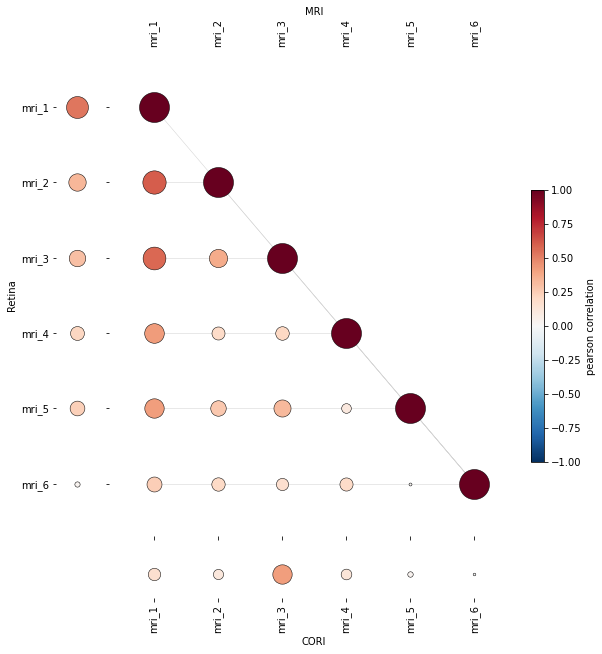

In [ ]:
"""
Triangular correlation heatmap with two "edge" correlation strips.

Layout (matches the sketch):

    Retina  ┌───────────────────────┐
    (rows)  │   lower-triangle       │
            │   corr heatmap of      │
            │   `main_vars`          │
            └───────────────────────┘
                      MRI (cols)
            ┌───────────────────────┐
            │   CORI strip           │
            └───────────────────────┘

- Dot size AND color both encode the correlation (size = |r|, color = r).
- Left strip: corr(main_vars[i], side_var_left)
- Bottom strip: corr(main_vars[j], side_var_bottom)

Usage
-----
fig, axes = triangle_corr_plot(
    df,
    main_vars=["mri_1", "mri_2", "mri_3", "mri_4", "mri_5"],
    side_var_left="retina_score",
    side_var_bottom="cori_score",
)
fig.savefig("triangle_corr.png", dpi=200)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec


def _corr_series(df, vars_list, other):
    """Correlation of each var in vars_list against a single other variable."""
    return np.array([df[v].corr(df[other]) for v in vars_list])


def triangle_corr_plot(
    df: pd.DataFrame,
    main_vars: list,
    side_var_left: str,
    side_var_bottom: str,
    method: str = "pearson",
    size_scale: float = 900.0,
    cmap: str = "RdBu_r",
    vmin: float = -1.0,
    vmax: float = 1.0,
    figsize: tuple = (10, 10),
    label_main: str = "MRI",
    label_left: str = "Retina",
    label_bottom: str = "CORI",
):
    """
    Build a lower-triangle correlation heatmap of `main_vars`, flanked by:
      - a left strip: corr(each main_var, side_var_left)
      - a bottom strip: corr(each main_var, side_var_bottom)

    Parameters
    ----------
    df : DataFrame containing all variables.
    main_vars : list of column names for the triangular grid (rows == cols).
    side_var_left : column name correlated against main_vars for the left strip.
    side_var_bottom : column name correlated against main_vars for the bottom strip.
    method : correlation method passed to pandas .corr() ('pearson', 'spearman', 'kendall').
    size_scale : max marker area (points^2) for |correlation| == 1.
    cmap, vmin, vmax : shared color scale across all three panels.

    Returns
    -------
    fig, (ax_main, ax_left, ax_bottom)
    """
    n = len(main_vars)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)

    # --- compute correlations ---
    corr_mat = df[main_vars].corr(method=method).values
    left_corr = _corr_series(df, main_vars, side_var_left)
    bottom_corr = _corr_series(df, main_vars, side_var_bottom)

    # --- figure layout: main triangle (big), left strip (thin col), bottom strip (thin row) ---
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 2,
        width_ratios=[0.6, n],
        height_ratios=[n, 0.6],
        wspace=0.05, hspace=0.05,
        figure=fig,
    )

    ax_left = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[0, 1], sharey=ax_left)
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    # ---------- MAIN lower-triangle heatmap ----------
    for i in range(n):          # row index (y)
        for j in range(n):      # col index (x)
            if j > i:
                continue  # skip upper triangle -> keeps it a triangle
            r = corr_mat[i, j]
            ax_main.scatter(
                j, i,
                s=abs(r) * size_scale,
                c=[cmap_obj(norm(r))],
                edgecolors="black",
                linewidths=0.5,
                zorder=3,
            )
    # light connecting grid lines (optional, mimics the sketch's lattice)
    for i in range(n):
        ax_main.plot([0, i], [i, i], color="lightgray", lw=0.5, zorder=1)
    for j in range(n):
        ax_main.plot([j, n - 1], [j, n - 1], color="lightgray", lw=0.5, zorder=1)

    ax_main.set_xlim(-0.7, n - 0.3)
    ax_main.set_ylim(n - 0.3, -0.7)  # flip so row 0 is at top
    ax_main.set_xticks(range(n))
    ax_main.set_yticks(range(n))
    ax_main.set_xticklabels(main_vars, rotation=90)
    ax_main.set_yticklabels(main_vars)
    ax_main.set_xlabel(label_main)
    ax_main.xaxis.set_label_position("top")
    ax_main.tick_params(labelbottom=False, labeltop=True, labelleft=False)
    ax_main.set_frame_on(False)

    # ---------- LEFT strip: corr with side_var_left ----------
    for i in range(n):
        r = left_corr[i]
        ax_left.scatter(
            0, i,
            s=abs(r) * size_scale,
            c=[cmap_obj(norm(r))],
            edgecolors="black",
            linewidths=0.5,
        )
    ax_left.set_xlim(-0.5, 0.5)
    ax_left.set_ylim(n - 0.3, -0.7)
    ax_left.set_xticks([])
    ax_left.set_yticks(range(n))
    ax_left.set_yticklabels(main_vars)
    ax_left.set_ylabel(label_left)
    ax_left.set_frame_on(False)

    # ---------- BOTTOM strip: corr with side_var_bottom ----------
    for j in range(n):
        r = bottom_corr[j]
        ax_bottom.scatter(
            j, 0,
            s=abs(r) * size_scale,
            c=[cmap_obj(norm(r))],
            edgecolors="black",
            linewidths=0.5,
        )
    ax_bottom.set_ylim(-0.5, 0.5)
    ax_bottom.set_xlim(-0.7, n - 0.3)
    ax_bottom.set_yticks([])
    ax_bottom.set_xticks(range(n))
    ax_bottom.set_xticklabels(main_vars, rotation=90)
    ax_bottom.set_xlabel(label_bottom)
    ax_bottom.set_frame_on(False)

    # ---------- shared colorbar ----------
    sm = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_main, ax_left, ax_bottom], shrink=0.5, pad=0.02)
    cbar.set_label(f"{method} correlation")

    return fig, (ax_main, ax_left, ax_bottom)


if __name__ == "__main__":
    # ---- quick demo with synthetic data ----
    rng = np.random.default_rng(0)
    n_obs = 200
    mri_vars = [f"mri_{i}" for i in range(1, 7)]
    data = pd.DataFrame(
        {v: rng.normal(size=n_obs) for v in mri_vars}
    )
    # add some correlation structure
    for i, v in enumerate(mri_vars[1:], start=1):
        data[v] = data[mri_vars[0]] * (0.6 - 0.08 * i) + rng.normal(scale=0.7, size=n_obs)

    data["retina_score"] = data["mri_1"] * 0.5 + rng.normal(scale=0.8, size=n_obs)
    data["cori_score"] = data["mri_3"] * 0.4 + rng.normal(scale=0.8, size=n_obs)

    fig, axes = triangle_corr_plot(
        data,
        main_vars= ['feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6'],
        side_var_left="retina_score",
        side_var_bottom="cori_score",
    )
    fig.savefig("./triangle_corr_demo.png", dpi=200, bbox_inches="tight")
    print("Saved demo figure.")

In [ ]:


SCRIPT_DIR = "./data/"
SOURCE_FILE = os.path.join(SCRIPT_DIR, "source_population_with_retinal_scores.csv")
CLINICAL_FILE = os.path.join(SCRIPT_DIR, "final_df_HTN_DB_Status.csv")
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "outputs")

COVARIATE_FORMULA = "age + female + height + C(center) + HTN + Diabetes"
A = "A_cancer"
Y = "Y_mace"
N_REP = 500
SEED = 42


def load_and_merge_data():
    df1 = pd.read_csv(SOURCE_FILE)
    df2 = pd.read_csv(CLINICAL_FILE, usecols=["eid", "HTN", "Diabetes"])

    df = df1.merge(df2, on="eid", how="left")
    assert df[["HTN", "Diabetes"]].isna().sum().sum() == 0, (
        "Unexpected missing HTN/Diabetes after merge - eid overlap assumption violated"
    )

    n_before = len(df)
    df = df.dropna(subset=["height"]).copy()
    print(f"Dropped {n_before - len(df)} rows with missing height ({n_before} -> {len(df)})")

    df[A] = df[A].astype(int)
    df[Y] = df[Y].astype(int)
    df["female"] = df["female"].astype(int)
    df["HTN"] = df["HTN"].astype(int)
    df["Diabetes"] = df["Diabetes"].astype(int)

    return df



df = load_and_merge_data()
df['eid'] = df['eid'].astype(str)


cmr = load_csv(CARDIAC_MRI_CSV, logger)
cmr["eid"] = clean_id(cmr["eid"])
cmr_long = reshape_cmr_long(cmr, instances=(2,3))




Dropped 154 rows with missing height (41822 -> 41668)
Loading CSV: data/cardiac_mri.csv


In [ ]:
cmr_vars = cmr_long.columns.tolist()[1:]

# select dtype flaot    
cmr_vars = [x for x in cmr_vars if np.issubdtype(cmr_long[x].dtype, np.floating)]
# remove low variance

# scale to 0-1
cmr_long[cmr_vars] = (cmr_long[cmr_vars] - cmr_long[cmr_vars].min()) / (cmr_long[cmr_vars].max() - cmr_long[cmr_vars].min())

print("len of cmr_vars before filtering:", len(cmr_vars))


len of cmr_vars before filtering: 217


In [ ]:

handcradted_df = pd.read_csv('./figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv')
handcradted_df['eid'] = handcradted_df['eid'].astype(str)

hand_Craft_fetureslist = [
    "HC_vessel_fundus_ring_125_175STD_branch_length",
    "HC_vessel_fundus_ring_125_175STD_branch_distance",
    "HC_vessel_fundus_ring_125_175pixel_degree_3",
    "HC_vein_fundus_ring_125_175total_connected_pixels",
    "HC_vein_fundus_ring_125_175pixel_degree_2",
]


triangleplot_df = df.merge(cmr_long[['eid']+ cmr_vars], on="eid", how="inner")

triangleplot_df = triangleplot_df.merge(handcradted_df[['eid'] + hand_Craft_fetureslist], on="eid", how="left")



In [ ]:

cmr_vars = [x for x in cmr_vars if triangleplot_df[x].var() > 1e-2]
print("len of cmr_vars after filtering:", len(cmr_vars))


# find cmr_vars that are not missing for more than 50% of the rows
cmr_vars = [x for x in cmr_vars if triangleplot_df[x].notna().mean() > 0.2]
print("len of cmr_vars after filtering for missingness:", len(cmr_vars))

len of cmr_vars after filtering: 101
len of cmr_vars after filtering for missingness: 51


In [ ]:
# select cmr var that are mosst corr with cori scaore

correlations = triangleplot_df[cmr_vars].corrwith(triangleplot_df['M_CORI_z'])
cmr_vars = correlations[correlations.abs() > 0.05].index.tolist()
print("len of cmr_vars after selecting most correlated:", len(cmr_vars))

len of cmr_vars after selecting most correlated: 16


Saved demo figure (shape='full').


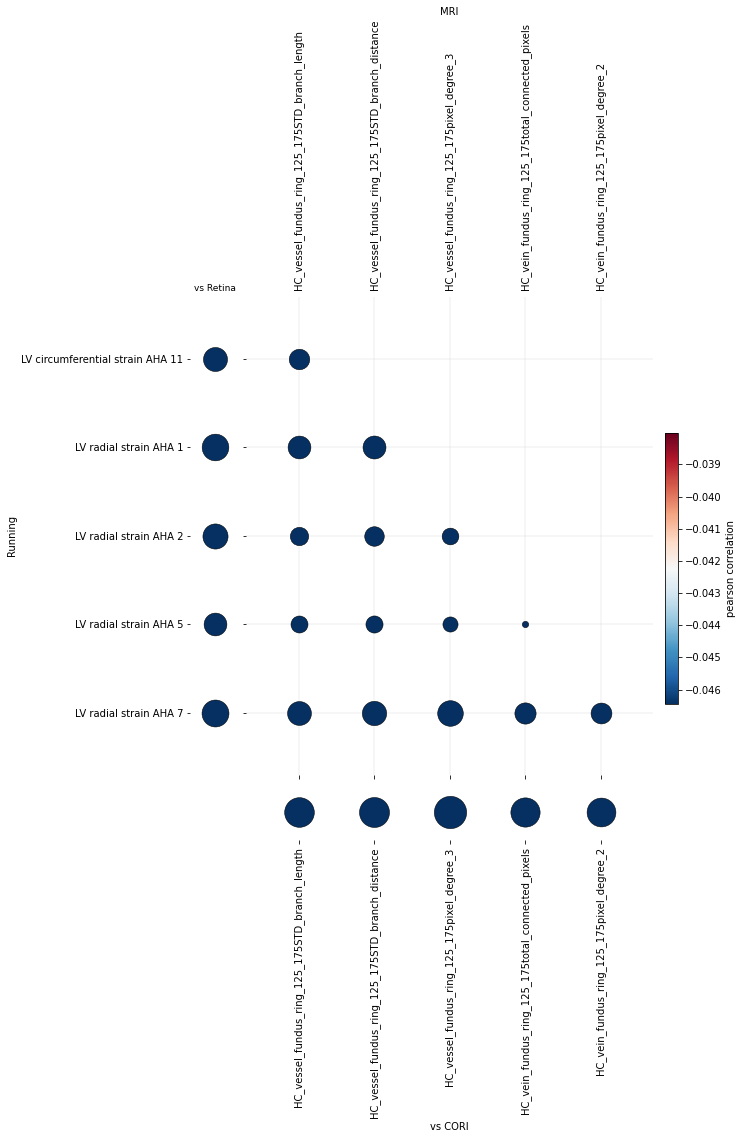

In [ ]:
"""
Triangular correlation heatmap with two "edge" correlation strips.

Layout (matches the sketch):

    Retina  ┌───────────────────────┐
    (rows)  │   lower-triangle       │
            │   corr heatmap of      │
            │   `main_vars`          │
            └───────────────────────┘
                      MRI (cols)
            ┌───────────────────────┐
            │   CORI strip           │
            └───────────────────────┘

- Dot size AND color both encode the correlation (size = |r|, color = r).
- Left strip: corr(main_vars[i], side_var_left)
- Bottom strip: corr(main_vars[j], side_var_bottom)

Usage
-----
fig, axes = triangle_corr_plot(
    df,
    main_vars=["mri_1", "mri_2", "mri_3", "mri_4", "mri_5"],
    side_var_left="retina_score",
    side_var_bottom="cori_score",
)
fig.savefig("triangle_corr.png", dpi=200)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec


def _corr_series(df, vars_list, other, method="pearson"):
    """Correlation of each var in vars_list against a single other variable."""
    return np.array([df[v].corr(df[other], method=method) for v in vars_list])


def _cross_corr_matrix(df, row_vars, col_vars, method="pearson"):
    """corr_mat[i, j] = corr(row_vars[i], col_vars[j])."""
    return np.array(
        [[df[r].corr(df[c], method=method) for c in col_vars] for r in row_vars]
    )


def triangle_corr_plot(
    df: pd.DataFrame,
    row_vars: list,
    col_vars: list,
    side_var_left: str,
    side_var_bottom: str,
    method: str = "pearson",
    shape: str = "lower",
    size_scale: float = 9900.0,
    cmap: str = "RdBu_r",
    vmin: float = -1.0,
    vmax: float = 1.0,
    figsize: tuple = (10, 10),
    label_row: str = "Row vars",
    label_col: str = "Col vars",
    label_left: str = None,
    label_bottom: str = None,
):
    """
    Cross-correlation heatmap between two DIFFERENT variable lists (row_vars on the
    y-axis, col_vars on the x-axis), flanked by two edge strips that reuse those
    same lists:
      - left strip:   corr(row_vars[i], side_var_left)   -- same list as the y-axis
      - bottom strip: corr(col_vars[j], side_var_bottom) -- same list as the x-axis

    Parameters
    ----------
    df : DataFrame containing all variables.
    row_vars : list of column names for the y-axis of the main grid.
    col_vars : list of column names for the x-axis of the main grid.
    side_var_left : column name correlated against row_vars for the left strip.
    side_var_bottom : column name correlated against col_vars for the bottom strip.
    method : correlation method ('pearson', 'spearman', 'kendall').
    shape : 'lower' (default) shows only cells where col index <= row index, giving
        the staircase/triangle look from the sketch. Since row_vars and col_vars are
        different, corr(row_i, col_j) != corr(row_j, col_i) in general -- 'lower'
        DISCARDS the cells above the staircase rather than mirroring redundant ones.
        Use shape='full' to see every row_vars x col_vars combination instead.
    size_scale : max marker area (points^2) for |correlation| == 1.
    cmap, vmin, vmax : shared color scale across all three panels.

    Returns
    -------
    fig, (ax_main, ax_left, ax_bottom)
    """
    assert shape in ("lower", "full")
    n_rows, n_cols = len(row_vars), len(col_vars)
    label_left = label_left or side_var_left
    label_bottom = label_bottom or side_var_bottom
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)

    # --- compute correlations ---
    corr_mat = _cross_corr_matrix(df, row_vars, col_vars, method=method)  # (n_rows, n_cols)
    left_corr = _corr_series(df, row_vars, side_var_left, method=method)   # (n_rows,)
    bottom_corr = _corr_series(df, col_vars, side_var_bottom, method=method)  # (n_cols,)

    # --- figure layout: main grid (big), left strip (thin col), bottom strip (thin row) ---
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        2, 2,
        width_ratios=[0.6, n_cols],
        height_ratios=[n_rows, 0.6],
        wspace=0.03, hspace=0.03,
        figure=fig,
    )

    ax_left = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[0, 1], sharey=ax_left)
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    # ---------- MAIN grid: row_vars (y) x col_vars (x) ----------
    for i in range(n_rows):          # row index (y)
        for j in range(n_cols):      # col index (x)
            if shape == "lower" and j > i:
                continue  # keep only the staircase, like the sketch
            r = corr_mat[i, j]
            ax_main.scatter(
                j, i,
                s=abs(r) * size_scale,
                c=[cmap_obj(norm(r))],
                edgecolors="black",
                linewidths=0.5,
                zorder=3,
            )
    # faint reference grid
    for i in range(n_rows):
        ax_main.axhline(i, color="lightgray", lw=0.4, zorder=1)
    for j in range(n_cols):
        ax_main.axvline(j, color="lightgray", lw=0.4, zorder=1)

    ax_main.set_xlim(-0.7, n_cols - 0.3)
    ax_main.set_ylim(n_rows - 0.3, -0.7)  # flip so row 0 is at top
    ax_main.set_xticks(range(n_cols))
    ax_main.set_yticks(range(n_rows))
    ax_main.set_xticklabels(col_vars, rotation=90)
    ax_main.set_yticklabels(row_vars)
    ax_main.set_xlabel(label_col)
    ax_main.xaxis.set_label_position("top")
    ax_main.tick_params(labelbottom=False, labeltop=True, labelleft=False)
    ax_main.set_frame_on(False)

    # ---------- LEFT strip: row_vars corr with side_var_left ----------
    for i in range(n_rows):
        r = left_corr[i]
        ax_left.scatter(
            0, i,
            s=abs(r) * size_scale,
            c=[cmap_obj(norm(r))],
            edgecolors="black",
            linewidths=0.5,
        )
    ax_left.set_xlim(-0.5, 0.5)
    ax_left.set_ylim(n_rows - 0.3, -0.7)
    ax_left.set_xticks([])
    ax_left.set_yticks(range(n_rows))
    ax_left.set_yticklabels(row_vars)
    ax_left.set_ylabel(label_row)
    ax_left.set_title(label_left, fontsize=9)
    ax_left.set_frame_on(False)

    # ---------- BOTTOM strip: col_vars corr with side_var_bottom ----------
    for j in range(n_cols):
        r = bottom_corr[j]
        ax_bottom.scatter(
            j, 0,
            s=abs(r) * size_scale,
            c=[cmap_obj(norm(r))],
            edgecolors="black",
            linewidths=0.5,
        )
    ax_bottom.set_ylim(-0.5, 0.5)
    ax_bottom.set_xlim(-0.7, n_cols - 0.3)
    ax_bottom.set_yticks([])
    ax_bottom.set_xticks(range(n_cols))
    ax_bottom.set_xticklabels(col_vars, rotation=90)
    ax_bottom.set_xlabel(label_bottom)
    ax_bottom.set_frame_on(False)

    # ---------- shared colorbar ----------
    sm = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_main, ax_left, ax_bottom], shrink=0.5, pad=0.02)
    cbar.set_label(f"{method} correlation")

    # return fig, (ax_main, ax_left, ax_bottom)


triangle_corr_plot(
    triangleplot_df,
    row_vars=cmr_vars[:5],
    col_vars=hand_Craft_fetureslist,
    side_var_left="M_CORI_z",
    side_var_bottom="M_CORI_z",
    # shape="full",
    label_row="Running",
    label_col="MRI",
    label_left="vs Retina",
    label_bottom="vs CORI",
    cmap = "RdBu_r",
    vmin = None,
        vmax = None,
        figsize = (10, 10)
)
print("Saved demo figure (shape='full').")

In [ ]:
triangleplot_df[  cmr_vars ]

,LV circumferential strain AHA 11,LV radial strain AHA 1,LV radial strain AHA 2,LV radial strain AHA 5,LV radial strain AHA 7,LV radial strain AHA 8,LV radial strain AHA 13,LV radial strain global,RV end diastolic volume,RV end systolic volume,Central systolic blood pressure during PWA - PVR| Array 0,Central systolic blood pressure during PWA - PVR| Array 1,"Systolic blood pressure, automated reading| Array 0",Systolic brachial blood pressure during PWA - PVR| Array 0,Systolic brachial blood pressure during PWA - PVR| Array 1,Systolic brachial blood pressure - OSC
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.613861,0.603960,0.479381,0.628713,0.628713,0.628713
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.666209,0.452406,0.464633,0.561656,0.472798,0.521678,0.437303,0.669477,0.293911,0.204204,0.673267,0.673267,0.438144,0.722772,0.722772,0.722772
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.657537,0.375228,0.248555,0.404644,0.431441,0.459583,0.316347,0.517227,0.250239,0.219377,0.539604,0.539604,0.371134,0.603960,0.603960,0.603960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.549505,0.549505,0.360825,0.559406,0.559406,0.559406
14119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.801980,0.792079,0.608247,0.866337,0.866337,0.866337


In [ ]:
triangleplot_df.columns.to_list()

['eid',
 'A_cancer',
 'Y_mace',
 'time_years',
 'age',
 'female',
 'height',
 'center',
 'analysis_role',
 'M_CORI_raw',
 'M_CORI_z',
 'M_MMACE_raw',
 'M_MMACE_z',
 'HTN',
 'Diabetes',
 'LV mean myocardial wall thickness AHA 2',
 'LV mean myocardial wall thickness global',
 'LV circumferential strain AHA 1',
 'LV circumferential strain AHA 2',
 'LV circumferential strain AHA 3',
 'LV circumferential strain AHA 4',
 'LV circumferential strain AHA 5',
 'LV circumferential strain AHA 6',
 'LV circumferential strain AHA 7',
 'LV circumferential strain AHA 9',
 'LV circumferential strain AHA 10',
 'LV circumferential strain AHA 11',
 'LV circumferential strain AHA 12',
 'LV circumferential strain AHA 14',
 'LV circumferential strain AHA 15',
 'LV circumferential strain AHA 16',
 'LV radial strain AHA 1',
 'LV radial strain AHA 2',
 'LV radial strain AHA 3',
 'LV radial strain AHA 4',
 'LV radial strain AHA 5',
 'LV radial strain AHA 6',
 'LV radial strain AHA 7',
 'LV radial strain AHA 8',


# End